# Single-unit fixation responses

Per-unit characterization of how BLA, ACCg, dmPFC and OFC neurons respond to the
three fixation categories — **face fixations during interactive periods**, **face
fixations during non-interactive periods**, and **object fixations**.

The notebook is organized as a hierarchy that narrows at each step:

| § | Scope | Question |
|---|---|---|
| 1 | All recorded units | What was recorded, and where? |
| 2 | Hand-picked exemplars | What do individual responses look like (PSTH + raster)? |
| 3 | All recorded units | What fraction of neurons does what? |
| 4 | All recorded units | How temporally specific is each unit's response? |
| 5 | Fixation-category-modulated units | Within the responsive subpopulation, who are the exemplars and how are the metrics distributed? |

Every analysis reads **precomputed tables** written by the `scripts/ephys/analysis/`
builders; nothing here re-scans the raw trial store except the example-unit raster
panels in §2, which need 1 ms spike trains.

**Environment:** the `gaze_processing` conda env.

## 0 · Environment, configuration, and inputs

In [1]:
from __future__ import annotations

from io import BytesIO
from pathlib import Path
import sys
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy import stats

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = next(parent for parent in Path.cwd().parents if (parent / "src").exists())
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

from dal_monte_2022_analysis.config.load import load_config
from dal_monte_2022_analysis.core.stats import adjust_pvalues
from dal_monte_2022_analysis.ephys.analysis.fixation_temporal_specificity import (
    METRIC_AXES,
    METRIC_LABELS,
    METRIC_NAMES,
    METRIC_SPECS,
)
from dal_monte_2022_analysis.runtime.io.analysis_index import build_analysis_output_dir
from dal_monte_2022_analysis.runtime.io.processed_data import load_pickle_path

dataset_cfg = load_config(repo_root / "configs" / "dataset.yaml")
psth_cfg = load_config(repo_root / "configs" / "ephys_fixation_psth.yaml")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 80)
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams.update(
    {
        "figure.dpi": 130,
        "savefig.dpi": 220,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": "#e6e6e6",       # recessive grid: present, never competing with the marks
        "grid.linewidth": 0.6,
        "axes.axisbelow": True,
        "font.size": 9,
        "axes.titlesize": 10,
        "legend.frameon": False,
    }
)


def show(fig, *, dpi=170):
    """Rasterize and display, so the notebook file stays a manageable size."""
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=dpi, bbox_inches="tight")
    plt.close(fig)
    buffer.seek(0)
    display(Image(data=buffer.getvalue()))


print("repo_root:          ", repo_root)
print("processed data root:", dataset_cfg["processed_data_root"])
print("analysis out root:  ", dataset_cfg["analysis_output_root"])

repo_root:           /gpfs/milgram/pi/chang/pg496/repositories/dal_monte_2022_analysis
processed data root: /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/data_files
analysis out root:   /gpfs/milgram/pi/chang/pg496/repositories/local_data/dal_monte_2022/analysis_outputs


### Shared vocabulary

Region order, condition colors and labels are pulled from `configs/ephys_fixation_psth.yaml`
so every figure here matches the ones the plotting scripts emit.

Design note on color: **region is encoded on the axis, never in hue.** Only the three
fixation conditions get a categorical palette, and it is the same fixed three-hue
assignment used everywhere else in the project (magenta / yellow-green / brown —
separable under deuteranopia, and additionally distinguished by hatch or marker
wherever they appear as fills).

In [2]:
REGIONS = list(psth_cfg.get("peakiness_plot_region_order", ["bla", "accg", "dmpfc", "ofc"]))
REGION_LABELS = dict(psth_cfg.get("peakiness_plot_region_labels", {}))
REGION_LABELS = {region: REGION_LABELS.get(region, region.upper()) for region in REGIONS}

CONDITIONS = ["face_interactive", "face_non_interactive", "object"]
CONDITION_COLORS = dict(psth_cfg.get("plot_condition_colors", {}))
CONDITION_LABELS = {
    "face_interactive": "Interactive face",
    "face_non_interactive": "Non-interactive face",
    "object": "Object",
}
# Secondary encoding so condition identity never rests on hue alone.
CONDITION_HATCHES = {"face_interactive": "", "face_non_interactive": "///", "object": "..."}

PAIRS = [
    "face_interactive__vs__face_non_interactive",
    "face_interactive__vs__object",
    "face_non_interactive__vs__object",
]
PAIR_LABELS = {
    "face_interactive__vs__face_non_interactive": "Int face vs Non-int face",
    "face_interactive__vs__object": "Int face vs Object",
    "face_non_interactive__vs__object": "Non-int face vs Object",
}
WINDOWS = ["pre_fix", "peri_fix", "post_fix"]
WINDOW_LABELS = {
    "pre_fix": "Pre-fix\n(−500–0 ms)",
    "peri_fix": "Peri-fix\n(−250–250 ms)",
    "post_fix": "Post-fix\n(0–500 ms)",
}

# Phasic/tonic exemplar styling, shared with plot_fixation_peakiness.
STYLE_COLORS = dict(psth_cfg.get("peakiness_plot_highlight_style_colors", {}))
STYLE_MARKERS = dict(psth_cfg.get("peakiness_plot_highlight_style_markers", {}))
STYLE_LABELS = {"phasic": "High temporal specificity", "tonic": "Low temporal specificity"}

BAR_FILL = "#9fb3c8"        # neutral fill for region bars (region is an axis, not a series)
BAR_EDGE = "#31485c"
ACCENT = "#c03a2b"

ALPHA = float(psth_cfg.get("selective_alpha", 0.05))
CORRECTION = str(psth_cfg.get("selective_pvalue_correction", "fdr_bh"))


def region_label(region: object) -> str:
    return REGION_LABELS.get(str(region), str(region).upper())


def bare_uuid(value: object) -> str:
    return str(value).replace("unit_uuid__", "")


print("regions:   ", [region_label(r) for r in REGIONS])
print("conditions:", CONDITIONS)
print(f"alpha={ALPHA}, multiple-comparison correction={CORRECTION}")

regions:    ['BLA', 'ACCg', 'dmPFC', 'OFC']
conditions: ['face_interactive', 'face_non_interactive', 'object']
alpha=0.05, multiple-comparison correction=fdr_bh


### Load the precomputed analysis tables

In [3]:
ANALYSIS_ROOT = build_analysis_output_dir(dataset_cfg, "ephys/psth")

SELECTIVITY_DIR = ANALYSIS_ROOT / "fixation_psth_selectivity"
DOMINANCE_DIR = ANALYSIS_ROOT / "fixation_condition_dominance"
PEAKINESS_DIR = ANALYSIS_ROOT / "fixation_peakiness"
SPECIFICITY_DIR = ANALYSIS_ROOT / "fixation_temporal_specificity"
GRID_DIR = ANALYSIS_ROOT / "fixation_psth_selective_unit_plots"

OUT_DIR = ANALYSIS_ROOT / "single_unit_notebook"
OUT_DIR.mkdir(parents=True, exist_ok=True)

unit_selectivity = pd.read_csv(SELECTIVITY_DIR / "unit_selectivity.csv")
unit_selectivity = unit_selectivity.loc[
    unit_selectivity["comparison_label"].astype(str) == "three_condition_core"
].copy()

pair_selectivity = pd.read_csv(SELECTIVITY_DIR / "pair_selectivity__three_condition_core.csv")
window_means = pd.read_csv(SELECTIVITY_DIR / "condition_window_means.csv")
unit_dominance = pd.read_csv(DOMINANCE_DIR / "unit_condition_dominance.csv")
unit_peakiness = pd.read_csv(PEAKINESS_DIR / "unit_peakiness.csv")
unit_specificity = pd.read_csv(SPECIFICITY_DIR / "unit_temporal_specificity.csv")
condition_specificity = pd.read_csv(SPECIFICITY_DIR / "unit_condition_temporal_specificity.csv")
condition_traces = load_pickle_path(SPECIFICITY_DIR / "unit_condition_traces.pkl")

for name, frame in [
    ("unit_selectivity", unit_selectivity),
    ("pair_selectivity", pair_selectivity),
    ("unit_dominance", unit_dominance),
    ("unit_peakiness", unit_peakiness),
    ("unit_specificity", unit_specificity),
    ("condition_specificity", condition_specificity),
    ("condition_traces", condition_traces),
]:
    print(f"{name:24s} {frame.shape[0]:6d} rows x {frame.shape[1]:3d} cols")

unit_selectivity           1201 rows x  23 cols
pair_selectivity           3603 rows x  32 cols
unit_dominance             1201 rows x  29 cols
unit_peakiness             1201 rows x  43 cols
unit_specificity           1201 rows x  68 cols
condition_specificity      3603 rows x  33 cols
condition_traces           3603 rows x  13 cols


### One master unit table

Every per-unit table is keyed on `unit_key` (`<date>|unit_uuid__<id>`), so they join
cleanly. `units` below is the single frame the rest of the notebook filters.

`is_selective` uses the **FDR-corrected** flag throughout. The uncorrected flag is
kept as `is_selective_raw` for the sensitivity check in §3.

In [4]:
units = unit_selectivity.loc[
    :,
    [
        "unit_key",
        "date",
        "unit_uuid",
        "region",
        "spike_channel",
        "recorded_agent",
        "is_selective_unit_corrected",
        "is_selective_unit_raw",
        "n_selective_pairs_corrected",
        "selective_pairs_corrected",
    ],
].rename(
    columns={
        "is_selective_unit_corrected": "is_selective",
        "is_selective_unit_raw": "is_selective_raw",
        "n_selective_pairs_corrected": "n_selective_pairs",
        "selective_pairs_corrected": "selective_pairs",
    }
)

units = units.merge(
    unit_dominance.loc[:, ["unit_key", "dominant_condition", "dominance_status"]],
    on="unit_key",
    how="left",
)
units = units.merge(
    unit_peakiness.loc[:, ["unit_key", "peakiness_score", "best_peak_dominance", "best_peak_competition_ratio"]],
    on="unit_key",
    how="left",
)
units = units.merge(
    unit_specificity.loc[
        :,
        ["unit_key", "mean_fr_hz", "peak_fr_hz", "any_condition_modulated", "best_condition"]
        + list(METRIC_NAMES),
    ],
    on="unit_key",
    how="left",
)

units["region"] = units["region"].astype(str)
units["uuid"] = units["unit_uuid"].map(bare_uuid)
units["region_label"] = units["region"].map(region_label)
units["is_selective"] = units["is_selective"].astype(bool)
units["is_selective_raw"] = units["is_selective_raw"].astype(bool)

assert units["unit_key"].is_unique, "unit_key must uniquely identify a unit"
assert units[list(METRIC_NAMES)].notna().all().all(), "temporal-specificity metrics must be complete"

print(f"{len(units)} units, {units['is_selective'].sum()} fixation-category-modulated (FDR corrected)")
units.head(3)

1201 units, 574 fixation-category-modulated (FDR corrected)


,unit_key,date,unit_uuid,region,spike_channel,recorded_agent,is_selective,is_selective_raw,n_selective_pairs,selective_pairs,dominant_condition,dominance_status,peakiness_score,best_peak_dominance,best_peak_competition_ratio,mean_fr_hz,peak_fr_hz,any_condition_modulated,best_condition,mass_width_frac_50,effective_width_ms,lifetime_sparseness,peak_dominance,n_prominent_peaks,fwhm_frac,sustained_frac,roughness,autocorr_width_ms,modulation_index,peak_z,temporal_specificity_index,sustainedness_index,uuid,region_label
0,01022019|unit_uuid__2500,1022019,unit_uuid__2500,bla,SPK38,m1,True,True,1,face_interactive__vs__face_non_interactive,object,dominant,1.197460,0.542931,0.841855,0.825608,2.013578,True,object,0.280831,385.428119,0.301457,0.315469,5.178824,0.359976,0.667835,3.152363,32.266667,0.226128,6.654804,0.071963,0.211986,2500,BLA
1,01022019|unit_uuid__2501,1022019,unit_uuid__2501,bla,SPK39,m1,False,False,0,NaN,face_non_interactive,dominant,1.048774,0.561203,0.781887,4.582470,6.161856,True,object,0.241059,403.336700,0.365283,0.315981,4.095686,0.349678,0.652549,3.396333,41.309804,0.102427,6.657251,0.073181,0.192558,2501,BLA
2,01022019|unit_uuid__2502,1022019,unit_uuid__2502,bla,SPK41,m1,False,False,0,NaN,face_non_interactive,dominant,0.757099,0.545049,0.834698,4.924039,6.183575,True,object,0.266071,403.550225,0.327733,0.383674,3.916863,0.381184,0.674157,2.972494,56.776471,0.098124,5.900742,0.095767,0.227701,2502,BLA


## 1 · Recording inventory

How many well-isolated single units contributed to each region, and how many
fixations of each category they saw.

In [5]:
inventory = (
    units.groupby("region")
    .agg(
        n_units=("unit_key", "size"),
        n_sessions=("date", "nunique"),
        n_channels=("spike_channel", "nunique"),
        median_fr_hz=("mean_fr_hz", "median"),
    )
    .reindex(REGIONS)
)

trial_counts = (
    window_means.loc[window_means["window_name"] == "full_fix"]
    .merge(units.loc[:, ["unit_key", "region"]], on="unit_key", how="inner", suffixes=("", "_u"))
    .groupby("region_u" if "region_u" in window_means.columns else "region")
    .agg(
        median_n_int_face=("n_trials_face_interactive", "median"),
        median_n_nonint_face=("n_trials_face_non_interactive", "median"),
        median_n_object=("n_trials_object", "median"),
    )
    .reindex(REGIONS)
)

inventory = inventory.join(trial_counts)
inventory.index = [region_label(r) for r in inventory.index]
inventory.loc["Total"] = [
    inventory["n_units"].sum(),
    units["date"].nunique(),
    inventory["n_channels"].sum(),
    np.nan,
    np.nan,
    np.nan,
    np.nan,
]
display(inventory.round(1))

,n_units,n_sessions,n_channels,median_fr_hz,median_n_int_face,median_n_nonint_face,median_n_object
BLA,537.0,35.0,29.0,5.2,846.0,164.0,168.0
ACCg,236.0,19.0,48.0,3.0,883.0,161.5,199.0
dmPFC,187.0,17.0,33.0,4.4,883.0,167.0,168.0
OFC,241.0,14.0,32.0,5.9,768.0,170.0,144.0
Total,1201.0,42.0,142.0,NaN,NaN,NaN,NaN


## 2 · Example units — PSTH and raster

The two grids below are the example units already used for project figures, selected
in `configs/ephys_fixation_psth.yaml`. Each cell shows the 1 ms spike raster (trials
grouped and colored by fixation category) above the trial-averaged firing rate
(mean ± SEM, 20 ms Gaussian smoothing, 10 ms bins). Dotted verticals mark the three
statistical windows used in §3.

Rendering reads the 1 ms spike-train store and takes a few minutes per grid, so the
figures are cached to disk and only re-rendered when `FORCE_RERENDER = True`.

In [6]:
FORCE_RERENDER = False

from dal_monte_2022_analysis.ephys.plotting.fixation_psth import (
    DEFAULT_CONDITION_COLORS,
    FixationPSTHUnitPlotSettings,
)
from dal_monte_2022_analysis.ephys.plotting.fixation_psth_example_grid import (
    FixationPSTHExampleGridPlotSettings,
    parse_example_grid_unit_specs,
    plot_fixation_psth_example_grid,
)
from dal_monte_2022_analysis.ephys.plotting.fixation_psth_phasic_tonic_example_grid import (
    normalize_example_response_style,
    parse_phasic_tonic_example_grid_unit_specs,
    plot_fixation_psth_phasic_tonic_example_grid,
)

GRID_REGIONS = list(psth_cfg.get("selective_example_grid_regions", ["BLA", "ACCg", "dmPFC", "OFC"]))


def base_unit_plot_settings() -> FixationPSTHUnitPlotSettings:
    """Trial/average sources for one example-grid cell, matching the plotting scripts."""
    return FixationPSTHUnitPlotSettings(
        cfg_path=str(repo_root / "configs" / "dataset.yaml"),
        plotting_cfg_path=str(repo_root / "configs" / "plotting.yaml"),
        trial_input_modality=psth_cfg.get("trial_output_modality", "psth"),
        trial_input_filename=psth_cfg.get("plot_trial_input_filename", "fixations_psth_10ms.pkl"),
        raster_trial_input_modality=psth_cfg.get("trial_output_modality", "psth"),
        raster_trial_input_filename=psth_cfg.get(
            "plot_raster_trial_input_filename", "fixations_spike_train_1ms.pkl"
        ),
        use_precomputed_average_traces=True,
        average_trace_input_subdir=psth_cfg.get(
            "plot_average_input_subdir", "ephys/psth/fixation_psth_averages"
        ),
        average_trace_input_filename=psth_cfg.get(
            "plot_average_input_filename_split",
            psth_cfg.get("plot_average_input_filename", "fixations_psth_10ms.pkl"),
        ),
        average_trace_object_input_subdir=psth_cfg.get(
            "plot_average_object_input_subdir",
            psth_cfg.get("plot_average_input_subdir", "ephys/psth/fixation_psth_averages"),
        ),
        average_trace_object_input_filename=psth_cfg.get(
            "plot_average_object_input_filename",
            psth_cfg.get("plot_average_input_filename_unsplit", "fixations_psth_10ms.pkl"),
        ),
        allow_trial_trace_fallback=False,
        interactive_label=psth_cfg.get("interactive_high_label", "interactive"),
        use_parallel=False,
        parallelize_units=False,
        max_trials_per_condition=psth_cfg.get("plot_max_trials_per_condition", 300),
        random_seed=psth_cfg.get("plot_random_seed", 42),
        condition_colors=psth_cfg.get("plot_condition_colors", DEFAULT_CONDITION_COLORS),
        smooth_before_average=True,
        smoothing_sigma_ms=psth_cfg.get("plot_smoothing_sigma_ms", 20.0),
        bin_size_ms_fallback=psth_cfg.get("bin_size_ms", 10.0),
        window_pre_s=psth_cfg.get("window_pre_s", 1.0),
        window_post_s=psth_cfg.get("window_post_s", 1.0),
    )


def render_grid(*, filename, unit_specs, row_labels, row_keys, height_in, left_margin,
                top_margin, row_key_normalizer=None):
    """Render (or reuse) one example grid PNG and return its path."""
    path = GRID_DIR / f"{filename}.png"
    if path.exists() and not FORCE_RERENDER:
        print(f"[cached] {path.name}")
        return path
    settings = FixationPSTHExampleGridPlotSettings(
        unit_plot_settings=base_unit_plot_settings(),
        output_subdir="ephys/psth/fixation_psth_selective_unit_plots",
        output_filename=filename,
        output_extension="png",
        output_dpi=220,
        figure_width_in=9.6,
        figure_height_in=height_in,
        column_regions=GRID_REGIONS,
        row_preferences=row_keys,
        row_labels=row_labels,
        left_margin=left_margin,
        top_margin=top_margin,
        display_window_s=(-1.0, 1.0),
        show_rate_window_rectangles=True,
    )
    kwargs = {} if row_key_normalizer is None else {"row_key_normalizer": row_key_normalizer}
    result = plot_fixation_psth_example_grid(
        settings, unit_specs=unit_specs, allow_missing=False, **kwargs
    )
    print(f"[rendered] {result['output_path']} ({result['resolved_cells']}/{result['expected_cells']} cells)")
    return Path(result["output_path"])

### 2a · Fixation-preference exemplars (preference × region)

One unit per (region, preferred fixation category). Rows are the category the unit
fires most for over the full −500–500 ms window; columns are regions.

[cached] nb_preference_example_grid_3x4.png


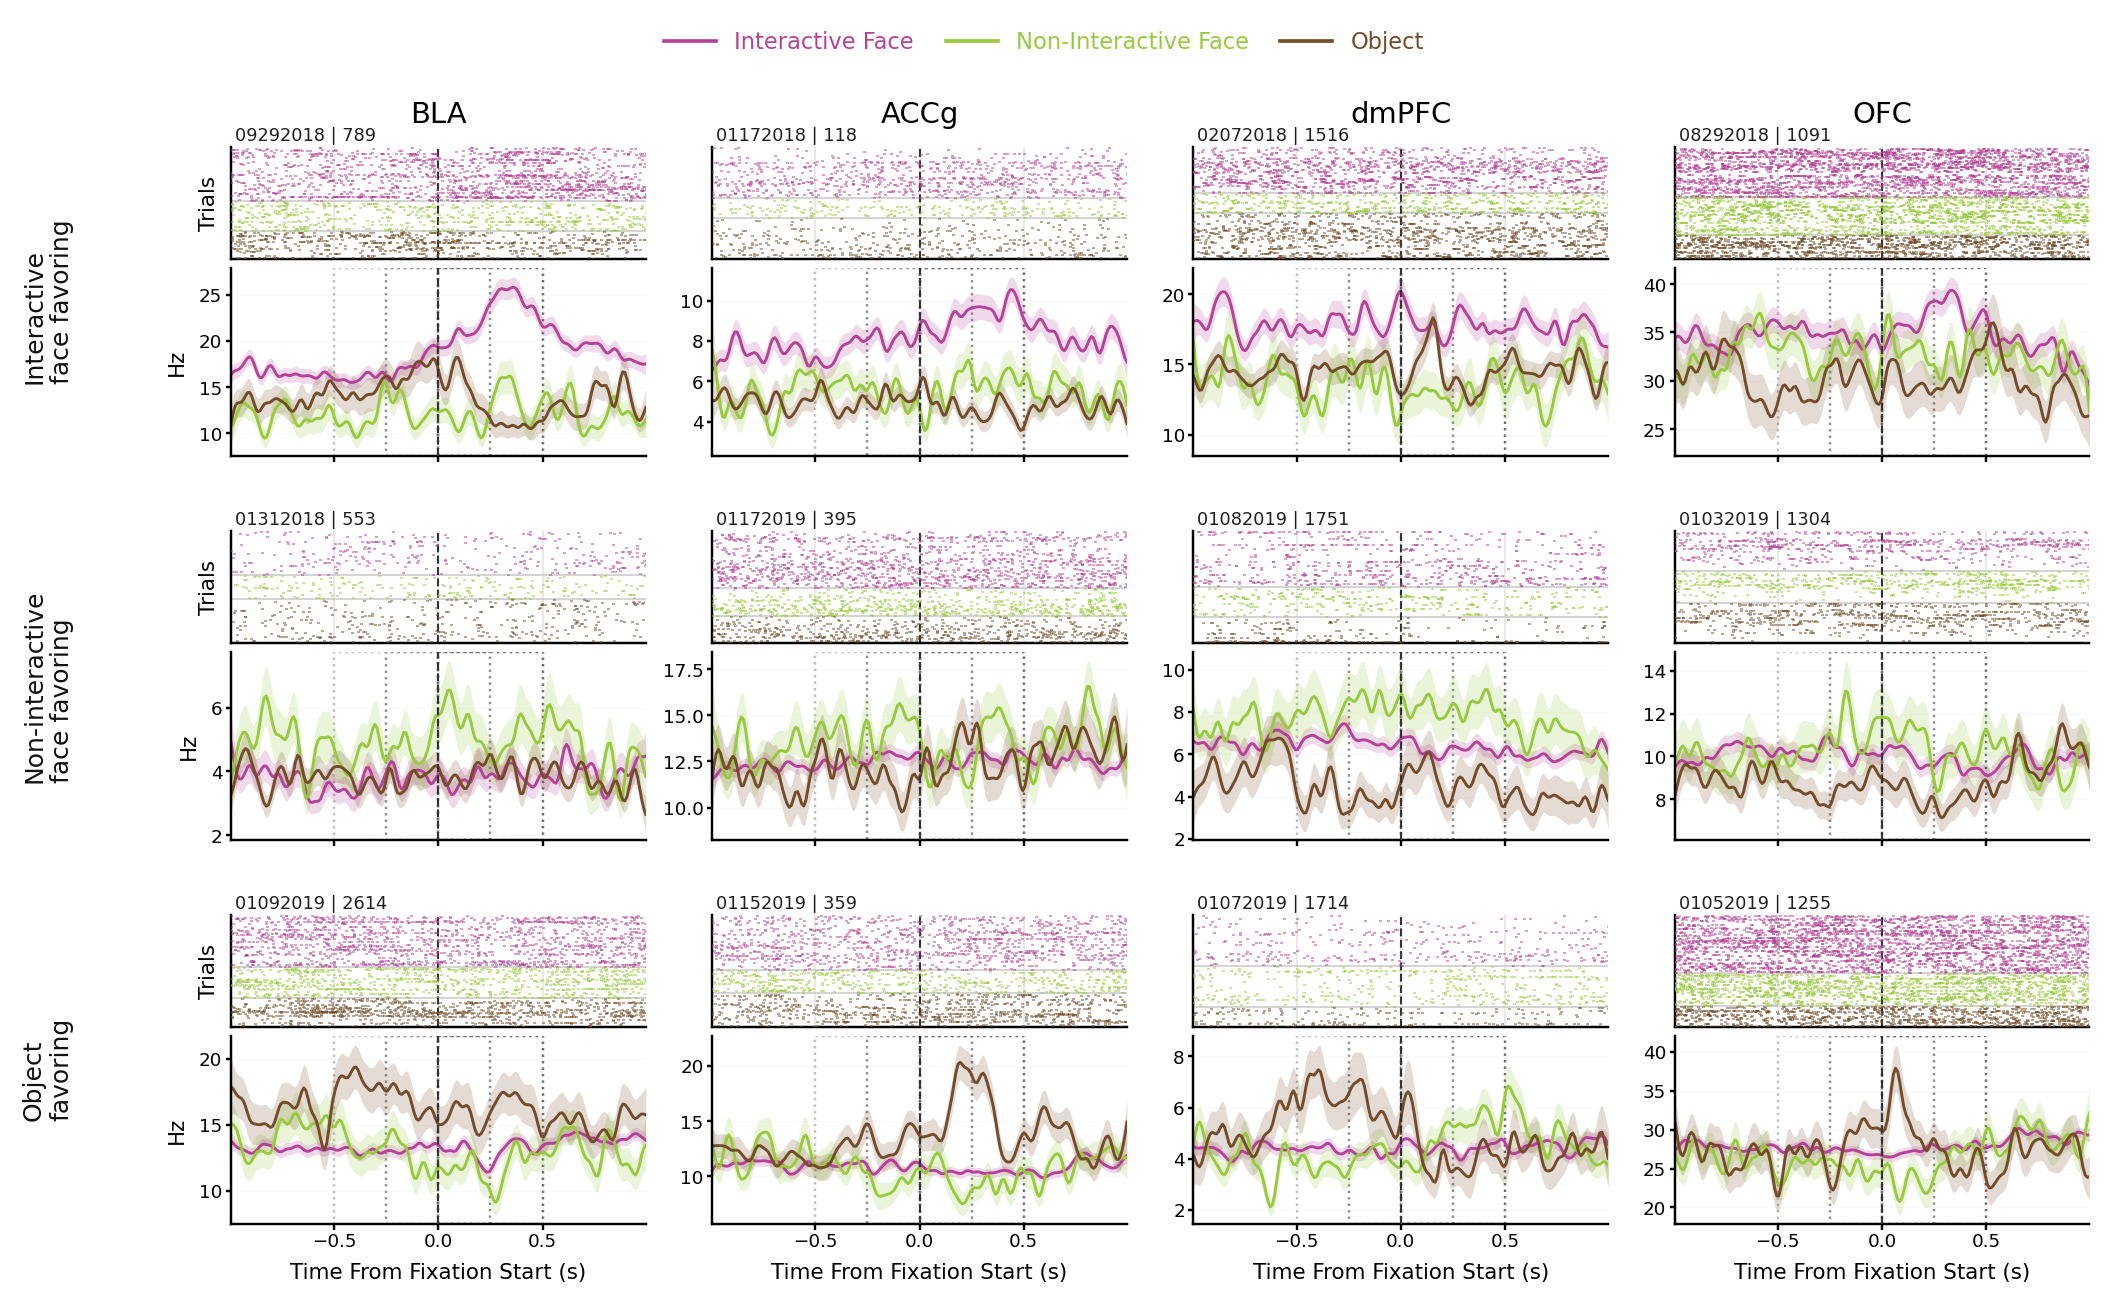

,region,row,unit_uuid,region_label,date,mean_fr_hz,is_selective,dominant_condition
0,BLA,face_interactive,789,BLA,9292018,18.01,True,face_interactive
1,BLA,face_non_interactive,553,BLA,1312018,4.05,True,face_non_interactive
2,BLA,object,2614,BLA,1092019,13.34,True,object
3,ACCg,face_interactive,118,ACCg,1172018,6.86,True,face_interactive
4,ACCg,face_non_interactive,395,ACCg,1172019,12.68,False,face_non_interactive
5,ACCg,object,359,ACCg,1152019,11.08,True,object
6,dmPFC,face_interactive,1516,dmPFC,2072018,16.11,True,face_interactive
7,dmPFC,face_non_interactive,1751,dmPFC,1082019,6.48,True,face_non_interactive
8,dmPFC,object,1714,dmPFC,1072019,4.44,True,object
9,OFC,face_interactive,1091,OFC,8292018,34.28,True,face_interactive


In [7]:
preference_specs = parse_example_grid_unit_specs(
    psth_cfg,
    regions=GRID_REGIONS,
    row_preferences=psth_cfg.get(
        "selective_example_grid_preferences",
        ["face_interactive", "face_non_interactive", "object"],
    ),
    cfg_key="selective_example_grid_units",
)
preference_path = render_grid(
    filename="nb_preference_example_grid_3x4",
    unit_specs=preference_specs,
    row_keys=list(psth_cfg.get("selective_example_grid_preferences", CONDITIONS)),
    row_labels={
        "face_interactive": "Interactive\nface favoring",
        "face_non_interactive": "Non-interactive\nface favoring",
        "object": "Object\nfavoring",
    },
    height_in=6.2,
    left_margin=0.115,
    top_margin=0.885,
)
display(Image(filename=str(preference_path)))

preference_table = pd.DataFrame(
    [{"region": s.region, "row": s.preference, "unit_uuid": s.unit_uuid} for s in preference_specs]
)
preference_table = preference_table.merge(
    units.loc[:, ["uuid", "region_label", "date", "mean_fr_hz", "is_selective", "dominant_condition"]],
    left_on="unit_uuid",
    right_on="uuid",
    how="left",
)
display(preference_table.drop(columns=["uuid"]).round(2))

### 2b · Temporal-specificity exemplars (high vs low)

The units previously labelled *phasic* / *tonic*. §4 tests, quantitatively, whether
these labels hold up — and one of them does not.

[cached] nb_temporal_specificity_example_grid_2x4.png


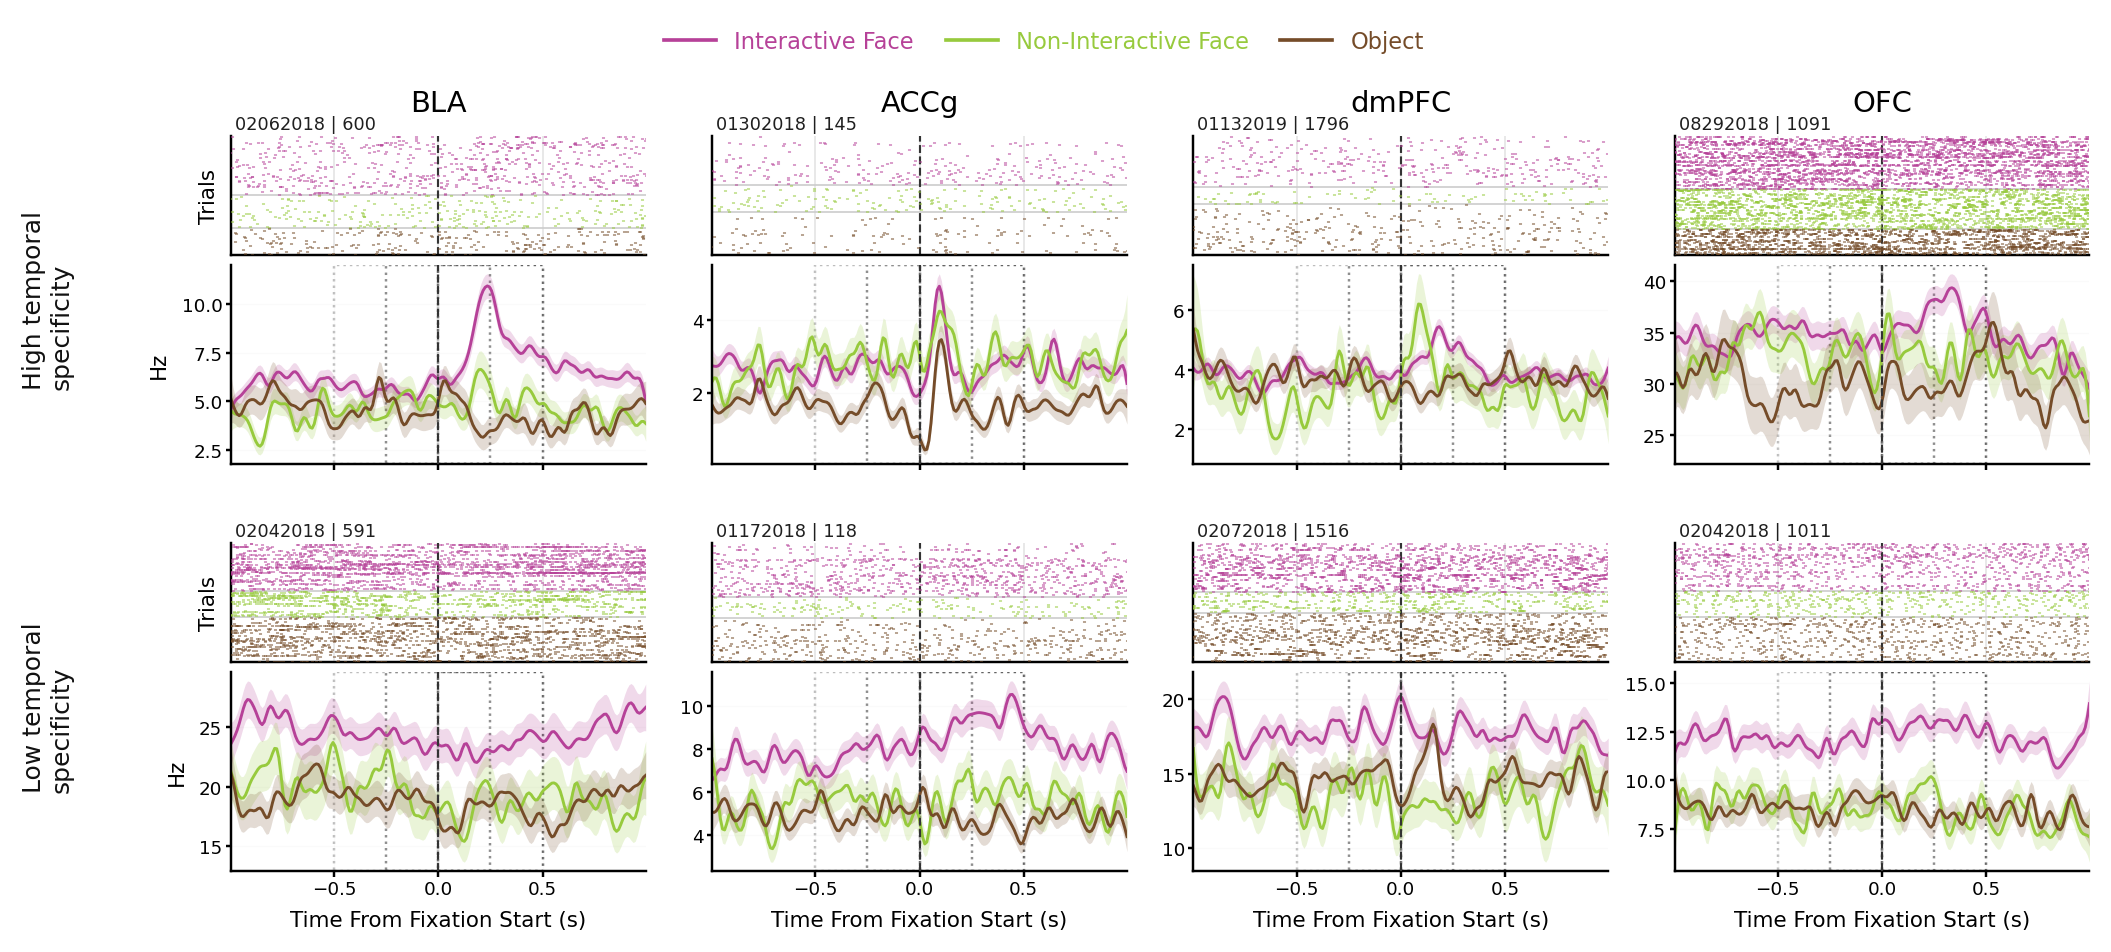

,style,region_label,uuid,date,mean_fr_hz,peak_fr_hz,is_selective
0,phasic,BLA,600,2062018,6.06,10.90,True
1,tonic,BLA,591,2042018,21.22,25.81,True
2,phasic,ACCg,145,1302018,2.47,4.94,True
3,tonic,ACCg,118,1172018,6.86,10.55,True
4,phasic,dmPFC,1796,1132019,3.95,6.19,True
5,tonic,dmPFC,1516,2072018,16.11,20.19,True
6,phasic,OFC,1091,8292018,34.28,39.37,True
7,tonic,OFC,1011,2042018,10.49,13.33,True


In [8]:
STYLE_SPECS = parse_phasic_tonic_example_grid_unit_specs(
    psth_cfg,
    regions=GRID_REGIONS,
    row_styles=["phasic", "tonic"],
)
style_path = render_grid(
    filename="nb_temporal_specificity_example_grid_2x4",
    unit_specs=STYLE_SPECS,
    row_keys=["phasic", "tonic"],
    row_labels={"phasic": "High temporal\nspecificity", "tonic": "Low temporal\nspecificity"},
    height_in=4.4,
    left_margin=0.115,
    top_margin=0.855,
    row_key_normalizer=normalize_example_response_style,
)
display(Image(filename=str(style_path)))

# Exemplar registry used by every later figure to mark where these units sit.
EXEMPLARS = pd.DataFrame(
    [{"style": s.preference, "region_key": s.region.lower(), "uuid": s.unit_uuid} for s in STYLE_SPECS]
).merge(units, on="uuid", how="left", suffixes=("", "_unit"))
EXEMPLARS = EXEMPLARS.loc[EXEMPLARS["region"] == EXEMPLARS["region_key"]].copy()
EXEMPLARS["label"] = EXEMPLARS["region_label"] + " " + EXEMPLARS["uuid"]
display(
    EXEMPLARS.loc[
        :, ["style", "region_label", "uuid", "date", "mean_fr_hz", "peak_fr_hz", "is_selective"]
    ].round(2)
)

## 3 · What fraction of neurons does what

Three nested questions, each answered with the count, the proportion with a 95%
Wilson confidence interval, and an explicit test:

1. **Is the unit modulated by fixation category at all?** A unit counts as
   *fixation-category-modulated* if the firing rate differs significantly between at
   least one of the three category pairs in at least one of the three windows
   (Welch's *t*-test on per-trial window-mean rates; **Benjamini–Hochberg FDR across
   all pair × window tests within a unit**).
2. **Which contrast drives it** — which pair, and in which window.
3. **Which category does it prefer** — the category with the highest mean rate over
   the full −500 to 500 ms window.

Windows: pre-fix (−500–0 ms), peri-fix (−250–250 ms), post-fix (0–500 ms).

In [9]:
def wilson_ci(k: int, n: int, *, z: float = 1.959963985) -> tuple[float, float]:
    """95% Wilson score interval for a binomial proportion.

    Wilson rather than Wald: several cells here have proportions near 0 or 1 with
    modest n, where the Wald interval leaves the unit interval.
    """
    if n <= 0:
        return (np.nan, np.nan)
    p = k / n
    denom = 1.0 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def proportion_table(numerators: pd.Series, denominators: pd.Series) -> pd.DataFrame:
    """Count / proportion / Wilson CI, one row per region."""
    rows = []
    for region in REGIONS:
        k = int(numerators.get(region, 0))
        n = int(denominators.get(region, 0))
        low, high = wilson_ci(k, n)
        rows.append(
            {
                "region": region,
                "region_label": region_label(region),
                "k": k,
                "n": n,
                "proportion": (k / n) if n else np.nan,
                "ci_low": low,
                "ci_high": high,
            }
        )
    return pd.DataFrame(rows)


def two_proportion_test(k1, n1, k2, n2) -> float:
    """Two-sided p-value for equality of two proportions (chi-square, 1 df)."""
    table = np.array([[k1, n1 - k1], [k2, n2 - k2]], dtype=float)
    if np.any(table.sum(axis=1) == 0) or np.any(table.sum(axis=0) == 0):
        return np.nan
    return float(stats.chi2_contingency(table, correction=False)[1])


def pairwise_region_tests(table: pd.DataFrame, *, label: str) -> pd.DataFrame:
    """All region pairs, FDR-corrected within the family."""
    rows = []
    for i, a in enumerate(REGIONS):
        for b in REGIONS[i + 1 :]:
            ra = table.loc[table["region"] == a].iloc[0]
            rb = table.loc[table["region"] == b].iloc[0]
            rows.append(
                {
                    "comparison": f"{region_label(a)} vs {region_label(b)}",
                    "prop_a": ra["proportion"],
                    "prop_b": rb["proportion"],
                    "p_value": two_proportion_test(ra["k"], ra["n"], rb["k"], rb["n"]),
                }
            )
    out = pd.DataFrame(rows)
    out["p_adj"] = adjust_pvalues(out["p_value"].to_numpy(), CORRECTION)
    out["significant"] = out["p_adj"] < ALPHA
    out.insert(0, "family", label)
    return out

### 3a · Fixation-category-modulated fraction, by region

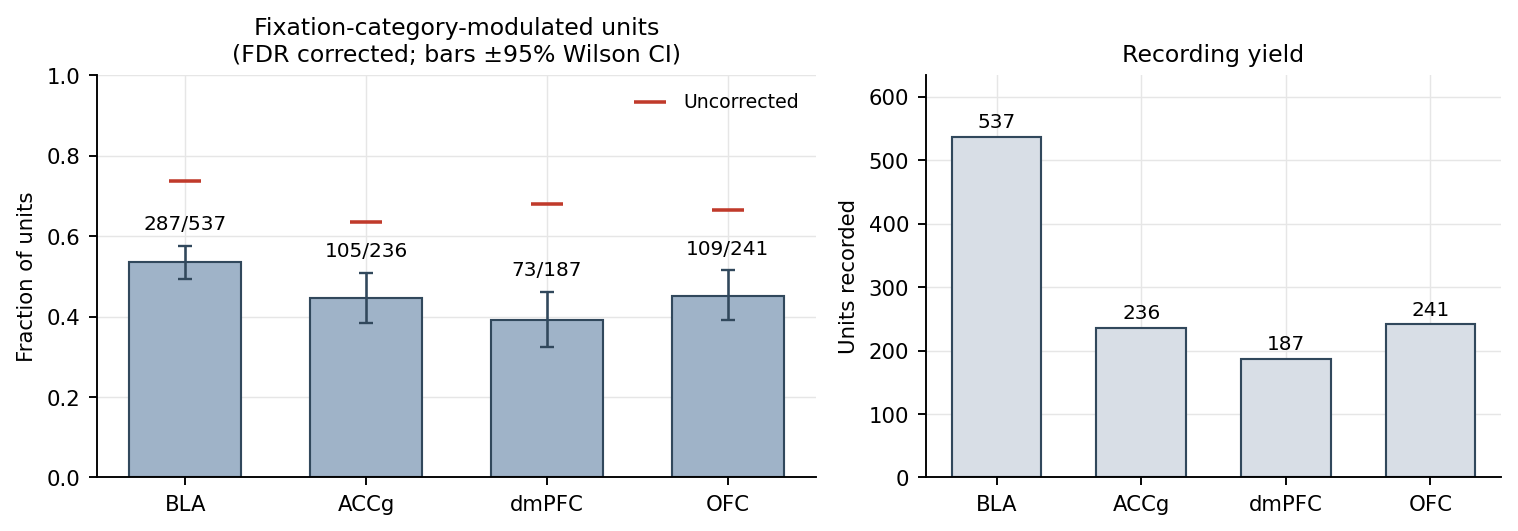

,region,region_label,k,n,proportion,ci_low,ci_high
0,bla,BLA,287,537,0.534,0.492,0.576
1,accg,ACCg,105,236,0.445,0.383,0.509
2,dmpfc,dmPFC,73,187,0.390,0.323,0.462
3,ofc,OFC,109,241,0.452,0.391,0.515


**Homogeneity across regions** (4×2 χ²): χ²(3) = 14.29, p = 2.54e-03

,family,comparison,prop_a,prop_b,p_value,p_adj,significant
0,modulated_fraction,BLA vs ACCg,0.5345,0.4449,0.0218,0.0655,False
1,modulated_fraction,BLA vs dmPFC,0.5345,0.3904,0.0007,0.0041,True
2,modulated_fraction,BLA vs OFC,0.5345,0.4523,0.0340,0.0680,False
3,modulated_fraction,ACCg vs dmPFC,0.4449,0.3904,0.2591,0.3110,False
4,modulated_fraction,ACCg vs OFC,0.4449,0.4523,0.8715,0.8715,False
5,modulated_fraction,dmPFC vs OFC,0.3904,0.4523,0.1988,0.2982,False


In [10]:
n_by_region = units.groupby("region").size()
modulated = proportion_table(units.loc[units["is_selective"]].groupby("region").size(), n_by_region)
modulated_raw = proportion_table(
    units.loc[units["is_selective_raw"]].groupby("region").size(), n_by_region
)

fig, axes = plt.subplots(1, 2, figsize=(9.0, 3.2), gridspec_kw={"width_ratios": [1.25, 1]})

ax = axes[0]
x = np.arange(len(REGIONS))
bars = ax.bar(
    x,
    modulated["proportion"],
    width=0.62,
    color=BAR_FILL,
    edgecolor=BAR_EDGE,
    linewidth=0.9,
)
ax.errorbar(
    x,
    modulated["proportion"],
    yerr=[
        modulated["proportion"] - modulated["ci_low"],
        modulated["ci_high"] - modulated["proportion"],
    ],
    fmt="none",
    ecolor=BAR_EDGE,
    elinewidth=1.1,
    capsize=3,
)
ax.scatter(x, modulated_raw["proportion"], marker="_", s=180, color=ACCENT, zorder=5,
           label="Uncorrected")
for xi, row in zip(x, modulated.itertuples()):
    ax.text(xi, row.ci_high + 0.03, f"{row.k}/{row.n}", ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels(modulated["region_label"])
ax.set_ylabel("Fraction of units")
ax.set_ylim(0, 1.0)
ax.set_title("Fixation-category-modulated units\n(FDR corrected; bars ±95% Wilson CI)")
ax.legend(loc="upper right", fontsize=8)

ax = axes[1]
ax.bar(x, n_by_region.reindex(REGIONS), width=0.62, color="#d8dee6", edgecolor=BAR_EDGE, linewidth=0.9)
for xi, value in zip(x, n_by_region.reindex(REGIONS)):
    ax.text(xi, value + 8, str(int(value)), ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(x)
ax.set_xticklabels([region_label(r) for r in REGIONS])
ax.set_ylabel("Units recorded")
ax.set_title("Recording yield")
ax.set_ylim(0, float(n_by_region.max()) * 1.18)

fig.tight_layout()
show(fig)

display(modulated.round(3))
homogeneity = stats.chi2_contingency(
    np.array([[r.k, r.n - r.k] for r in modulated.itertuples()], dtype=float), correction=False
)
display(
    Markdown(
        f"**Homogeneity across regions** (4×2 χ²): "
        f"χ²({homogeneity[2]}) = {homogeneity[0]:.2f}, p = {homogeneity[1]:.2e}"
    )
)
display(pairwise_region_tests(modulated, label="modulated_fraction").round(4))

### 3b · Which contrast drives the modulation

A unit can be modulated by more than one pair, so these bars overlap — they are not
a partition. The window breakdown counts, per region, in how many units each window
carried at least one significant pair.

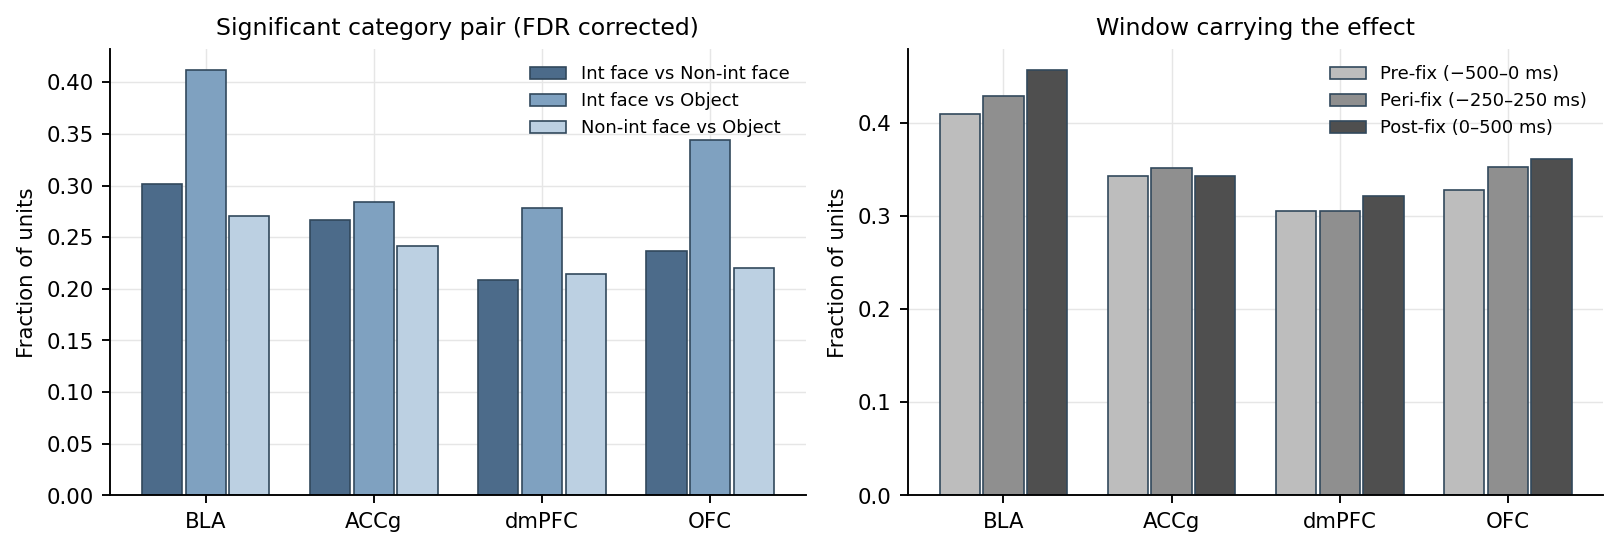

,Int face vs Non-int face,Int face vs Object,Non-int face vs Object
BLA,162,221,145
ACCg,63,67,57
dmPFC,39,52,40
OFC,57,83,53


,pre_fix,peri_fix,post_fix
BLA,220,230,245
ACCg,81,83,81
dmPFC,57,57,60
OFC,79,85,87


In [11]:
pair_sel = pair_selectivity.loc[pair_selectivity["comparison_label"] == "three_condition_core"].copy()
pair_sel["region"] = pair_sel["region"].astype(str)

pair_counts = (
    pair_sel.loc[pair_sel["is_selective_pair_corrected"].astype(bool)]
    .groupby(["region", "pair_label"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=REGIONS, columns=PAIRS, fill_value=0)
)


def window_hits(frame: pd.DataFrame) -> pd.DataFrame:
    """Per region, the number of units with a significant pair in each window."""
    rows = []
    significant = frame.loc[frame["is_selective_pair_corrected"].astype(bool)]
    for region in REGIONS:
        region_rows = significant.loc[significant["region"] == region]
        entry = {"region": region}
        for window in WINDOWS:
            mask = region_rows["significant_windows_corrected"].fillna("").str.contains(window, regex=False)
            entry[window] = int(region_rows.loc[mask, "unit_key"].nunique())
        rows.append(entry)
    return pd.DataFrame(rows).set_index("region").reindex(REGIONS)


window_counts = window_hits(pair_sel)

fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.3))

ax = axes[0]
width = 0.26
for offset, pair in zip((-width, 0.0, width), PAIRS):
    values = pair_counts[pair] / n_by_region.reindex(REGIONS)
    ax.bar(
        x + offset,
        values,
        width=width * 0.92,
        label=PAIR_LABELS[pair],
        color=["#4c6b8a", "#7fa1c0", "#bcd0e2"][PAIRS.index(pair)],
        edgecolor=BAR_EDGE,
        linewidth=0.7,
    )
ax.set_xticks(x)
ax.set_xticklabels([region_label(r) for r in REGIONS])
ax.set_ylabel("Fraction of units")
ax.set_title("Significant category pair (FDR corrected)")
ax.legend(fontsize=7.6, loc="upper right")

ax = axes[1]
for offset, window in zip((-width, 0.0, width), WINDOWS):
    values = window_counts[window] / n_by_region.reindex(REGIONS)
    ax.bar(
        x + offset,
        values,
        width=width * 0.92,
        label=WINDOW_LABELS[window].replace("\n", " "),
        color=["#bdbdbd", "#8f8f8f", "#4f4f4f"][WINDOWS.index(window)],
        edgecolor=BAR_EDGE,
        linewidth=0.7,
    )
ax.set_xticks(x)
ax.set_xticklabels([region_label(r) for r in REGIONS])
ax.set_ylabel("Fraction of units")
ax.set_title("Window carrying the effect")
ax.legend(fontsize=7.6, loc="upper right")

fig.tight_layout()
show(fig)

combined = pair_counts.copy()
combined.columns = [PAIR_LABELS[c] for c in combined.columns]
combined.index = [region_label(r) for r in combined.index]
display(combined)
window_display = window_counts.copy()
window_display.index = [region_label(r) for r in window_display.index]
display(window_display)

### 3c · Preferred fixation category among modulated units

Pie charts show the composition; the bar panel carries the confidence intervals,
because a pie cannot show uncertainty. Each region is tested against the null that
the three categories are equally often preferred (χ² goodness-of-fit vs. 1/3 each),
FDR corrected across regions.

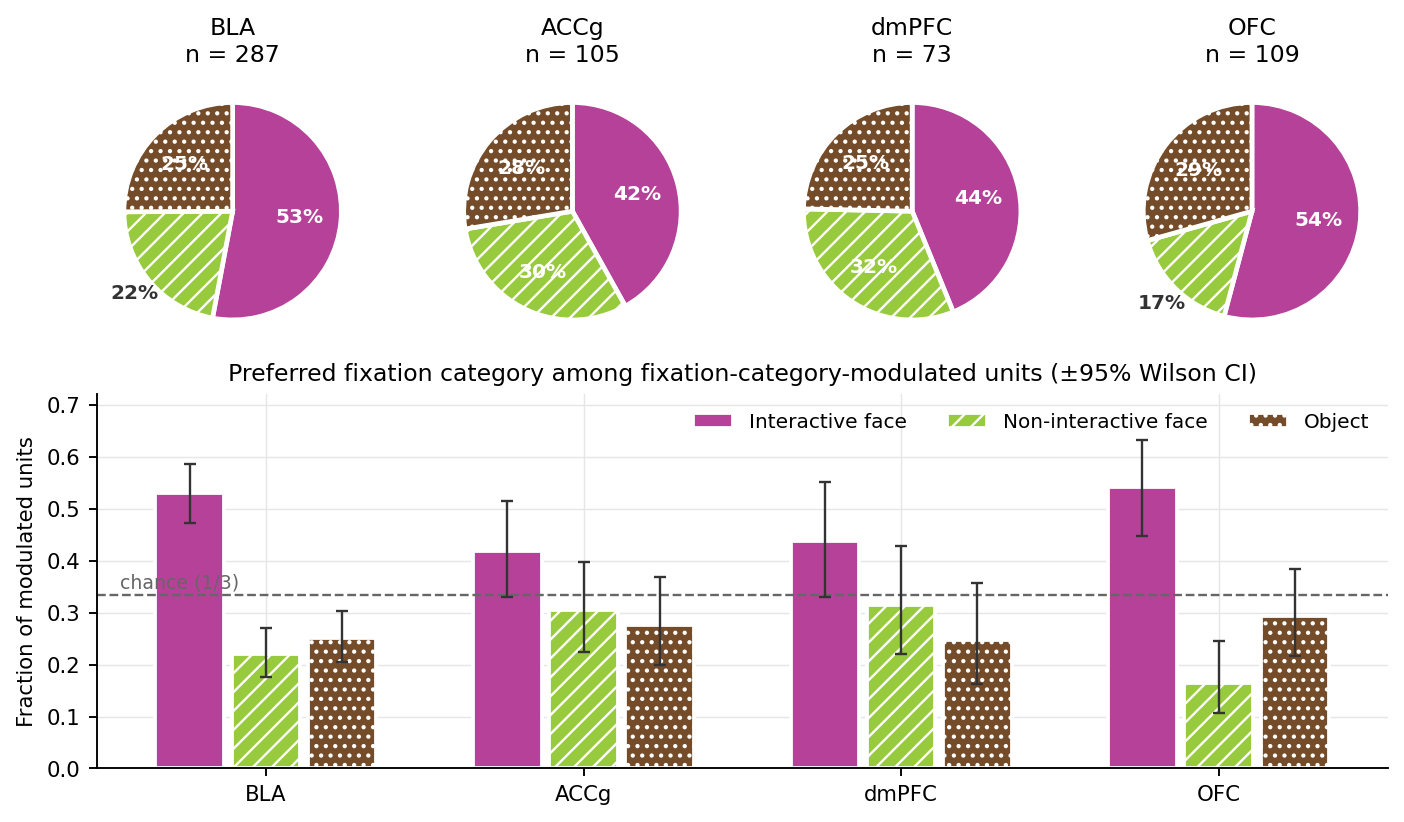

,region,n,Interactive face,Non-interactive face,Object,chi2_vs_uniform,p_value,p_adj,significant
0,BLA,287,152,63,72,50.1812,0.0000,0.0000,True
1,ACCg,105,44,32,29,3.6000,0.1653,0.1653,False
2,dmPFC,73,32,23,18,4.1370,0.1264,0.1653,False
3,OFC,109,59,18,32,23.9083,0.0000,0.0000,True


**Does the preference composition differ across regions?** 4×3 χ²(6) = 10.16, p = 0.118

,family,comparison,prop_a,prop_b,p_value,p_adj,significant
0,interactive_face_preference,BLA vs ACCg,0.5296,0.4190,0.0525,0.2208,False
1,interactive_face_preference,BLA vs dmPFC,0.5296,0.4384,0.1637,0.2602,False
2,interactive_face_preference,BLA vs OFC,0.5296,0.5413,0.8353,0.8353,False
3,interactive_face_preference,ACCg vs dmPFC,0.4190,0.4384,0.7978,0.8353,False
4,interactive_face_preference,ACCg vs OFC,0.4190,0.5413,0.0736,0.2208,False
5,interactive_face_preference,dmPFC vs OFC,0.4384,0.5413,0.1735,0.2602,False


In [12]:
selective_units = units.loc[units["is_selective"]].copy()
pref_counts = (
    selective_units.groupby(["region", "dominant_condition"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=REGIONS, columns=CONDITIONS, fill_value=0)
)
pref_totals = pref_counts.sum(axis=1)

fig = plt.figure(figsize=(9.8, 5.4))
gs = fig.add_gridspec(2, 4, height_ratios=[1.0, 1.25], hspace=0.10, wspace=0.25)

for col, region in enumerate(REGIONS):
    ax = fig.add_subplot(gs[0, col])
    values = pref_counts.loc[region]
    total = int(values.sum())
    wedges, _ = ax.pie(
        values,
        colors=[CONDITION_COLORS[c] for c in CONDITIONS],
        startangle=90,
        counterclock=False,
        wedgeprops={"edgecolor": "white", "linewidth": 2.0},  # 2px surface gap between segments
    )
    for wedge, condition in zip(wedges, CONDITIONS):
        wedge.set_hatch(CONDITION_HATCHES[condition])
    for wedge, value in zip(wedges, values):
        if value == 0:
            continue
        angle = np.deg2rad((wedge.theta1 + wedge.theta2) / 2.0)
        # Thin wedges cannot hold a legible inside label, so those go outside in
        # ink color rather than being squeezed onto the fill.
        outside = (value / total) < 0.22
        radius = 1.18 if outside else 0.62
        ax.text(
            radius * np.cos(angle),
            radius * np.sin(angle),
            f"{100 * value / total:.0f}%",
            ha="center",
            va="center",
            fontsize=8.5,
            color="#333333" if outside else "white",
            fontweight="bold",
        )
    ax.set_title(f"{region_label(region)}\nn = {total}", fontsize=10)

ax = fig.add_subplot(gs[1, :])
width = 0.24
gof_rows = []
for offset, condition in zip((-width, 0.0, width), CONDITIONS):
    table = proportion_table(pref_counts[condition], pref_totals)
    ax.bar(
        x + offset,
        table["proportion"],
        width=width * 0.9,
        color=CONDITION_COLORS[condition],
        edgecolor="white",
        linewidth=1.6,
        hatch=CONDITION_HATCHES[condition],
        label=CONDITION_LABELS[condition],
    )
    ax.errorbar(
        x + offset,
        table["proportion"],
        yerr=[table["proportion"] - table["ci_low"], table["ci_high"] - table["proportion"]],
        fmt="none",
        ecolor="#333333",
        elinewidth=1.0,
        capsize=2.5,
    )
ax.axhline(1 / 3, color="#666666", linestyle="--", linewidth=1.0, zorder=1)
ax.text(-0.46, 1 / 3 + 0.014, "chance (1/3)", fontsize=8, color="#666666", ha="left")
ax.set_xticks(x)
ax.set_xticklabels([region_label(r) for r in REGIONS])
ax.set_ylabel("Fraction of modulated units")
ax.set_ylim(0, 0.72)
ax.set_title("Preferred fixation category among fixation-category-modulated units (±95% Wilson CI)")
ax.legend(ncol=3, fontsize=8.5, loc="upper right")

show(fig)

for region in REGIONS:
    observed = pref_counts.loc[region].to_numpy(dtype=float)
    chi2, p = stats.chisquare(observed)[:2]
    gof_rows.append(
        {
            "region": region_label(region),
            "n": int(observed.sum()),
            **{CONDITION_LABELS[c]: int(v) for c, v in zip(CONDITIONS, observed)},
            "chi2_vs_uniform": chi2,
            "p_value": p,
        }
    )
gof = pd.DataFrame(gof_rows)
gof["p_adj"] = adjust_pvalues(gof["p_value"].to_numpy(), CORRECTION)
gof["significant"] = gof["p_adj"] < ALPHA
display(gof.round(4))

across = stats.chi2_contingency(pref_counts.to_numpy(dtype=float), correction=False)
display(
    Markdown(
        "**Does the preference composition differ across regions?** "
        f"4×3 χ²({across[2]}) = {across[0]:.2f}, p = {across[1]:.3f}"
    )
)

int_face = proportion_table(pref_counts["face_interactive"], pref_totals)
display(pairwise_region_tests(int_face, label="interactive_face_preference").round(4))

### 3d · The paragraph, with the numbers this pipeline currently produces

In [13]:
def fraction_phrase(table: pd.DataFrame) -> str:
    return ", ".join(
        f"{int(row.k)}/{int(row.n)} in {row.region_label}" for row in table.itertuples()
    )


yield_phrase = ", ".join(
    f"{int(n_by_region[region])} from {region_label(region)}" for region in REGIONS
)

display(
    Markdown(
        f"""
Single-unit responses were recorded simultaneously from BLA along with one of ACCg,
dmPFC, or OFC using multi-contact linear electrode arrays. Across all sessions,
**{yield_phrase}** single units were isolated ({len(units)} total, across
{units['date'].nunique()} sessions).

A large proportion of these neurons showed significant differences in firing rate for
at least one pair of the three fixation categories — face fixations during interactive
periods, face fixations during non-interactive periods, and object fixations —
(**{fraction_phrase(modulated)}**).

Among these fixation-category-modulated neurons, many preferentially responded to
interactive face fixations relative to the other fixation categories
(**{fraction_phrase(int_face)}**).
"""
    )
)


Single-unit responses were recorded simultaneously from BLA along with one of ACCg,
dmPFC, or OFC using multi-contact linear electrode arrays. Across all sessions,
**537 from BLA, 236 from ACCg, 187 from dmPFC, 241 from OFC** single units were isolated (1201 total, across
42 sessions).

A large proportion of these neurons showed significant differences in firing rate for
at least one pair of the three fixation categories — face fixations during interactive
periods, face fixations during non-interactive periods, and object fixations —
(**287/537 in BLA, 105/236 in ACCg, 73/187 in dmPFC, 109/241 in OFC**).

Among these fixation-category-modulated neurons, many preferentially responded to
interactive face fixations relative to the other fixation categories
(**152/287 in BLA, 44/105 in ACCg, 32/73 in dmPFC, 59/109 in OFC**).


> **Note on the numbers.** The modulated-fraction counts reproduce the manuscript
> paragraph exactly. The interactive-face-preference counts are **lower** than the
> figures quoted there (169/287, 54/105, 36/73, 62/109). The counts above come from
> `fixation_condition_dominance` with `dominant_condition` scored on the full
> −500–500 ms window; the manuscript numbers predate that builder. Whichever
> definition is adopted, it needs to be stated in the methods — the qualitative
> conclusion (interactive face is the modal preference in BLA, dmPFC and OFC, but not
> ACCg) is the same either way.

## 4 · Temporal specificity of the response

### The problem with the current score

`fixation_peakiness` reduces each average PSTH to prominences from
`scipy.signal.find_peaks`: the largest, `p1`; the largest outside a ±250 ms
exclusion window, `p2`; and the scaled ratio

$$\text{peakiness} = \frac{p_1}{1 + \lambda\, p_2 / p_1}, \qquad \lambda = 0.5$$

That answers *"is there one tall peak with no close rival?"* — but it conflates
things the traces in §2b show are different:

- it is **amplitude-carrying**, so a high-rate unit outscores a low-rate unit of
  identical shape;
- it is **blind to width**, so a 100 ms transient and a 600 ms plateau with the same
  prominence score the same;
- it **ignores raggedness beyond the runner-up**, so a trace with one tall peak and
  twenty small wiggles still scores well.

### The metrics used here

`fixation_temporal_specificity` scores the same average traces (−500 to 500 ms,
baseline = 10th percentile of the in-window trace) on four separated axes.

In [14]:
metric_doc = pd.DataFrame(
    [
        {
            "metric": spec["name"],
            "axis": spec["axis"],
            "label": spec["label"],
            "high value means": {
                "mass_width_frac_50": "excess response spread over many bins (broad)",
                "effective_width_ms": "wide equivalent-rectangle response (broad)",
                "lifetime_sparseness": "excess mass concentrated in few bins (peaky)",
                "peak_dominance": "one peak carries most of the total prominence (peaky)",
                "n_prominent_peaks": "many comparable peaks (ragged)",
                "fwhm_frac": "long time above half the excess peak (sustained)",
                "sustained_frac": "long time above 25% of the excess peak (sustained)",
                "roughness": "many monotone excursions (fluctuating)",
                "autocorr_width_ms": "slowly varying trace (smooth)",
                "modulation_index": "large peak relative to baseline",
                "peak_z": "peak large relative to trace noise",
                "temporal_specificity_index": "narrow + single-peaked + smooth",
                "sustainedness_index": "broadly elevated + smooth",
            }[spec["name"]],
        }
        for spec in METRIC_SPECS
    ]
)
display(metric_doc)

display(
    Markdown(
        """
The two composites are deliberately **not** negatives of each other:

- `temporal_specificity_index` = (1 − `mass_width_frac_50`) × `peak_dominance` × smoothness
- `sustainedness_index` = `sustained_frac` × smoothness

where smoothness = 1 / (1 + max(`roughness` − 1, 0)). A unit can be low on both
(flat, or ragged with no dominant peak), which is exactly the majority case.
"""
    )
)

,metric,axis,label,high value means
0,mass_width_frac_50,concentration,50% mass width (frac. of window),excess response spread over many bins (broad)
1,effective_width_ms,concentration,Effective width (ms),wide equivalent-rectangle response (broad)
2,lifetime_sparseness,concentration,Lifetime sparseness,excess mass concentrated in few bins (peaky)
3,peak_dominance,single_peak,Peak dominance (p1 / Σp),one peak carries most of the total prominence ...
4,n_prominent_peaks,single_peak,Prominent peaks (n),many comparable peaks (ragged)
5,fwhm_frac,sustainedness,FWHM (frac. of window),long time above half the excess peak (sustained)
6,sustained_frac,sustainedness,Sustained fraction (>25% excess),long time above 25% of the excess peak (sustai...
7,roughness,fluctuation,Roughness (total variation / range),many monotone excursions (fluctuating)
8,autocorr_width_ms,fluctuation,Autocorrelation half-width (ms),slowly varying trace (smooth)
9,modulation_index,amplitude,Modulation index,large peak relative to baseline



The two composites are deliberately **not** negatives of each other:

- `temporal_specificity_index` = (1 − `mass_width_frac_50`) × `peak_dominance` × smoothness
- `sustainedness_index` = `sustained_frac` × smoothness

where smoothness = 1 / (1 + max(`roughness` − 1, 0)). A unit can be low on both
(flat, or ragged with no dominant peak), which is exactly the majority case.


### 4a · Distribution of each metric, by region

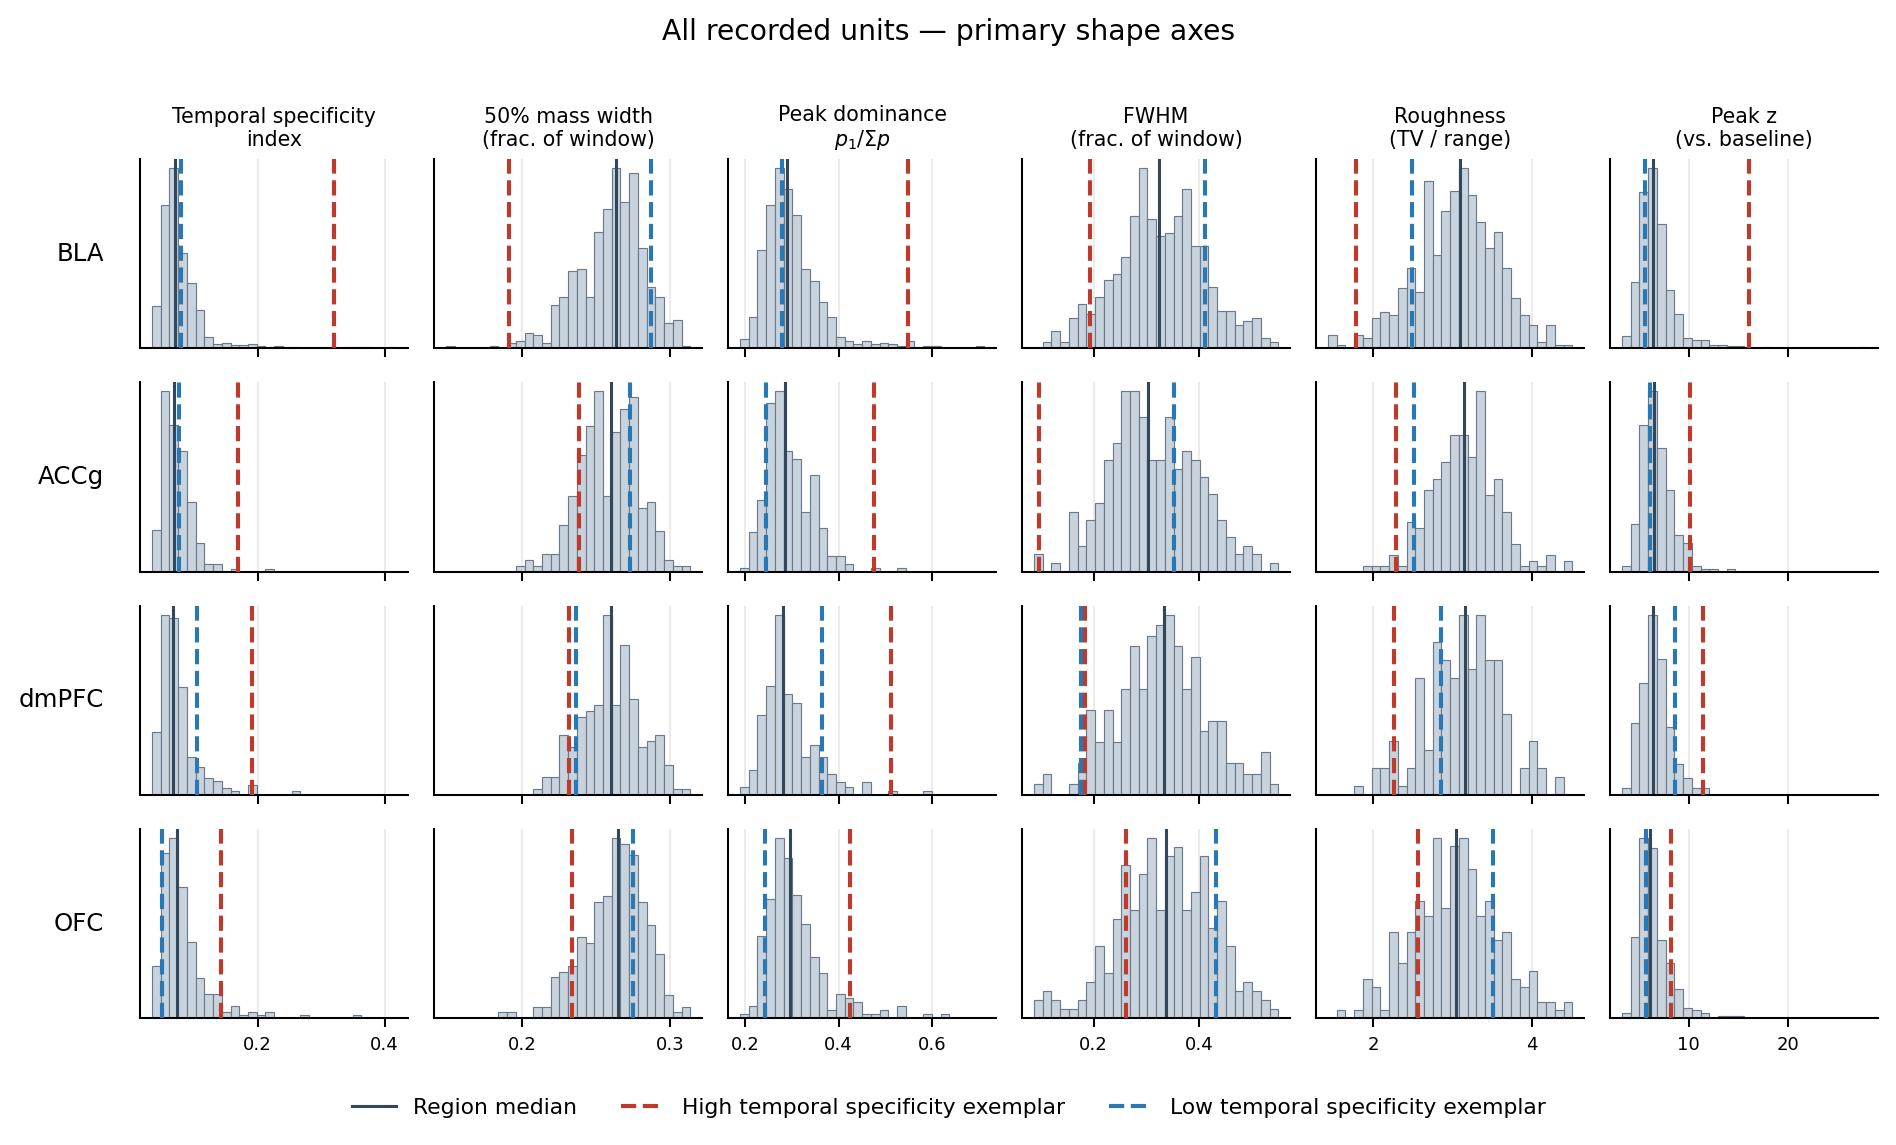

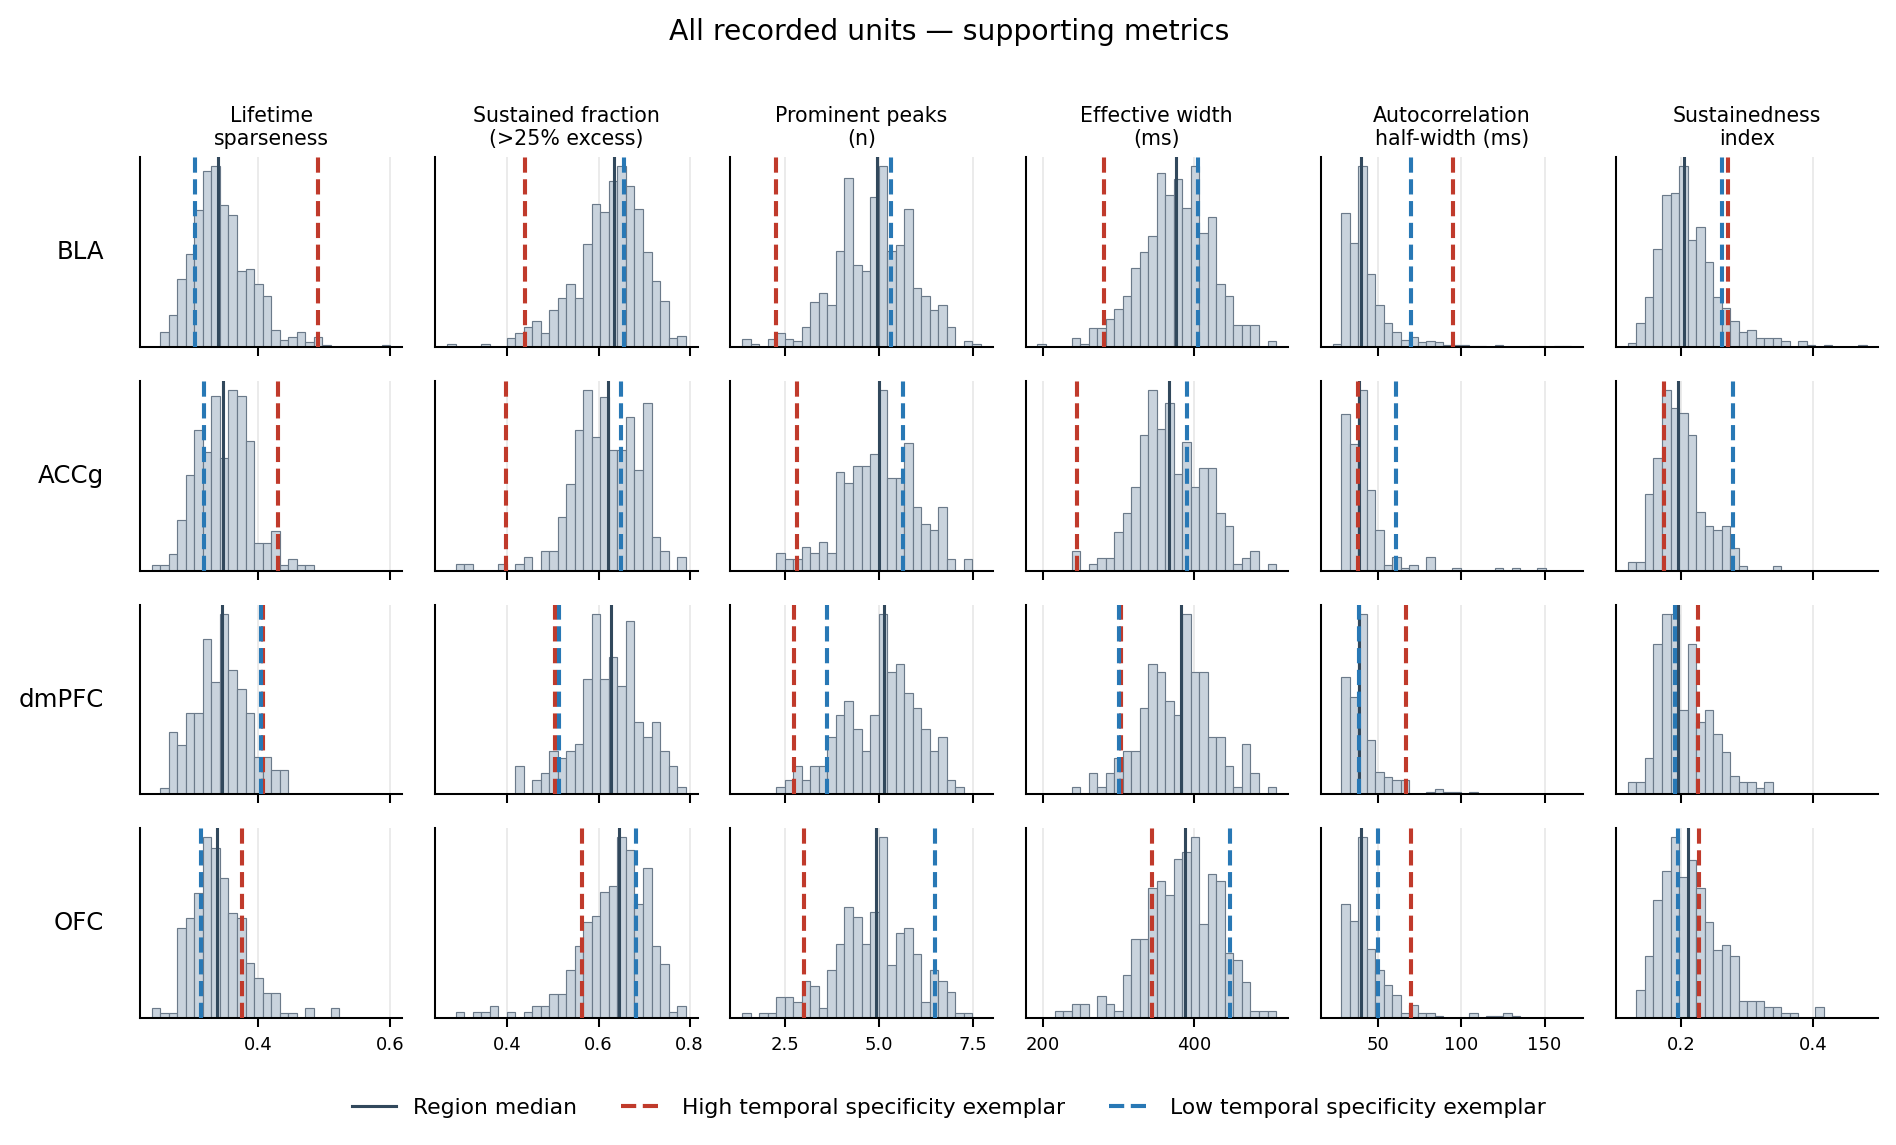

In [15]:
# Twelve metrics do not fit legibly in one row of panels, so they are shown as two
# figures: the shape axes that carry the argument, then the supporting quantities.
PRIMARY_METRICS = [
    "temporal_specificity_index",
    "mass_width_frac_50",
    "peak_dominance",
    "fwhm_frac",
    "roughness",
    "peak_z",
]
SECONDARY_METRICS = [
    "lifetime_sparseness",
    "sustained_frac",
    "n_prominent_peaks",
    "effective_width_ms",
    "autocorr_width_ms",
    "sustainedness_index",
]
HIST_METRICS = PRIMARY_METRICS + SECONDARY_METRICS

# Compact titles for panel headers; the full definitions stay in the table above.
SHORT_LABELS = {
    "temporal_specificity_index": "Temporal specificity\nindex",
    "mass_width_frac_50": "50% mass width\n(frac. of window)",
    "peak_dominance": "Peak dominance\n$p_1/\\Sigma p$",
    "fwhm_frac": "FWHM\n(frac. of window)",
    "roughness": "Roughness\n(TV / range)",
    "peak_z": "Peak z\n(vs. baseline)",
    "lifetime_sparseness": "Lifetime\nsparseness",
    "sustained_frac": "Sustained fraction\n(>25% excess)",
    "n_prominent_peaks": "Prominent peaks\n(n)",
    "effective_width_ms": "Effective width\n(ms)",
    "autocorr_width_ms": "Autocorrelation\nhalf-width (ms)",
    "sustainedness_index": "Sustainedness\nindex",
}


def metric_histograms(frame: pd.DataFrame, metrics, *, title, exemplars=None, bins=28):
    """Region rows × metric columns, with exemplar positions marked."""
    n_rows, n_cols = len(REGIONS), len(metrics)
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=(1.72 * n_cols, 1.42 * n_rows), sharex="col", squeeze=False
    )
    for row, region in enumerate(REGIONS):
        region_frame = frame.loc[frame["region"] == region]
        for col, metric in enumerate(metrics):
            ax = axes[row][col]
            values = pd.to_numeric(region_frame[metric], errors="coerce").dropna().to_numpy()
            edges = np.histogram_bin_edges(
                pd.to_numeric(frame[metric], errors="coerce").dropna().to_numpy(), bins=bins
            )
            ax.hist(values, bins=edges, color="#c9d3dd", edgecolor="#6b7a8a", linewidth=0.45)
            if values.size:
                ax.axvline(np.median(values), color="#31485c", linewidth=1.2, linestyle="-")
            if exemplars is not None:
                marked = exemplars.loc[exemplars["region"] == region]
                for _, unit in marked.iterrows():
                    value = unit.get(metric)
                    if value is None or not np.isfinite(value):
                        continue
                    ax.axvline(
                        value,
                        color=STYLE_COLORS.get(unit["style"], ACCENT),
                        linewidth=1.6,
                        linestyle="--",
                        zorder=6,
                    )
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(region_label(region), fontsize=9.5, rotation=0, ha="right", va="center",
                              labelpad=14)
            if row == 0:
                ax.set_title(SHORT_LABELS.get(metric, METRIC_LABELS[metric]), fontsize=8, pad=5)
            if row == n_rows - 1:
                ax.tick_params(axis="x", labelsize=7)
    handles = [Line2D([0], [0], color="#31485c", linewidth=1.2, label="Region median")] + [
        Line2D([0], [0], color=STYLE_COLORS.get(style, ACCENT), linewidth=1.6, linestyle="--",
               label=STYLE_LABELS[style] + " exemplar")
        for style in ("phasic", "tonic")
    ]
    fig.legend(handles=handles, ncol=3, loc="lower center", fontsize=8.5, bbox_to_anchor=(0.5, -0.055))
    fig.suptitle(title, fontsize=11, y=1.01)
    fig.tight_layout()
    return fig


show(
    metric_histograms(
        units, PRIMARY_METRICS, title="All recorded units — primary shape axes", exemplars=EXEMPLARS
    ),
    dpi=185,
)
show(
    metric_histograms(
        units, SECONDARY_METRICS, title="All recorded units — supporting metrics", exemplars=EXEMPLARS
    ),
    dpi=185,
)

### 4b · Where the exemplars actually fall

In [16]:
RANK_METRICS = [
    "temporal_specificity_index",
    "mass_width_frac_50",
    "lifetime_sparseness",
    "peak_dominance",
    "fwhm_frac",
    "sustained_frac",
    "roughness",
    "peak_z",
    "sustainedness_index",
]

ranks = units.copy()
for metric in RANK_METRICS:
    ranks[f"pct__{metric}"] = ranks.groupby("region")[metric].rank(pct=True)

exemplar_ranks = EXEMPLARS.loc[:, ["style", "region_label", "uuid"]].merge(
    ranks.loc[:, ["uuid", "region"] + [f"pct__{m}" for m in RANK_METRICS]],
    on="uuid",
    how="left",
)
exemplar_ranks = exemplar_ranks.rename(columns={f"pct__{m}": METRIC_LABELS[m] for m in RANK_METRICS})
exemplar_ranks = exemplar_ranks.drop(columns=["region"]).sort_values(["style", "region_label"])
display(
    exemplar_ranks.style.format(precision=2).background_gradient(
        cmap="Blues", subset=[METRIC_LABELS[m] for m in RANK_METRICS], vmin=0, vmax=1
    ).set_caption("Within-region percentile rank of each exemplar (1.00 = highest in its region)")
)

,style,region_label,uuid,Temporal specificity index,50% mass width (frac. of window),Lifetime sparseness,Peak dominance (p1 / Σp),FWHM (frac. of window),Sustained fraction (>25% excess),Roughness (total variation / range),Peak z (vs. window baseline),Sustainedness index
2,phasic,ACCg,145,1.00,0.14,0.98,1.00,0.01,0.01,0.02,0.97,0.23
0,phasic,BLA,600,0.99,0.01,0.99,0.99,0.06,0.02,0.01,1.00,0.90
6,phasic,OFC,1091,0.94,0.10,0.81,0.94,0.20,0.16,0.20,0.87,0.64
4,phasic,dmPFC,1796,0.99,0.10,0.93,0.99,0.04,0.07,0.06,0.99,0.73
3,tonic,ACCg,118,0.62,0.74,0.25,0.13,0.69,0.64,0.06,0.36,0.98
1,tonic,BLA,591,0.63,0.89,0.17,0.41,0.85,0.62,0.13,0.26,0.88
7,tonic,OFC,1011,0.08,0.70,0.25,0.10,0.86,0.74,0.82,0.34,0.39
5,tonic,dmPFC,1516,0.89,0.13,0.93,0.89,0.03,0.09,0.27,0.91,0.42


Read the table above against the traces in §2b. The four *high specificity*
exemplars sit at the top of their region for `temporal_specificity_index` and
`peak_z` and at the bottom for `fwhm_frac`, which is what the label claims. Three of
the four *low specificity* exemplars sit mid-to-low, as expected.

**dmPFC 1516 is mislabelled.** It ranks high on the specificity index and low on
FWHM — its trace in §2b is a fluctuating, multi-peaked one rather than a sustained
plateau. It is also the interactive-face exemplar in §2a, so it was probably chosen
for its preference and inherited the *tonic* label. §5c proposes replacements
selected on the metrics rather than by eye.

### 4c · Are the metrics redundant, and what does the old score capture?

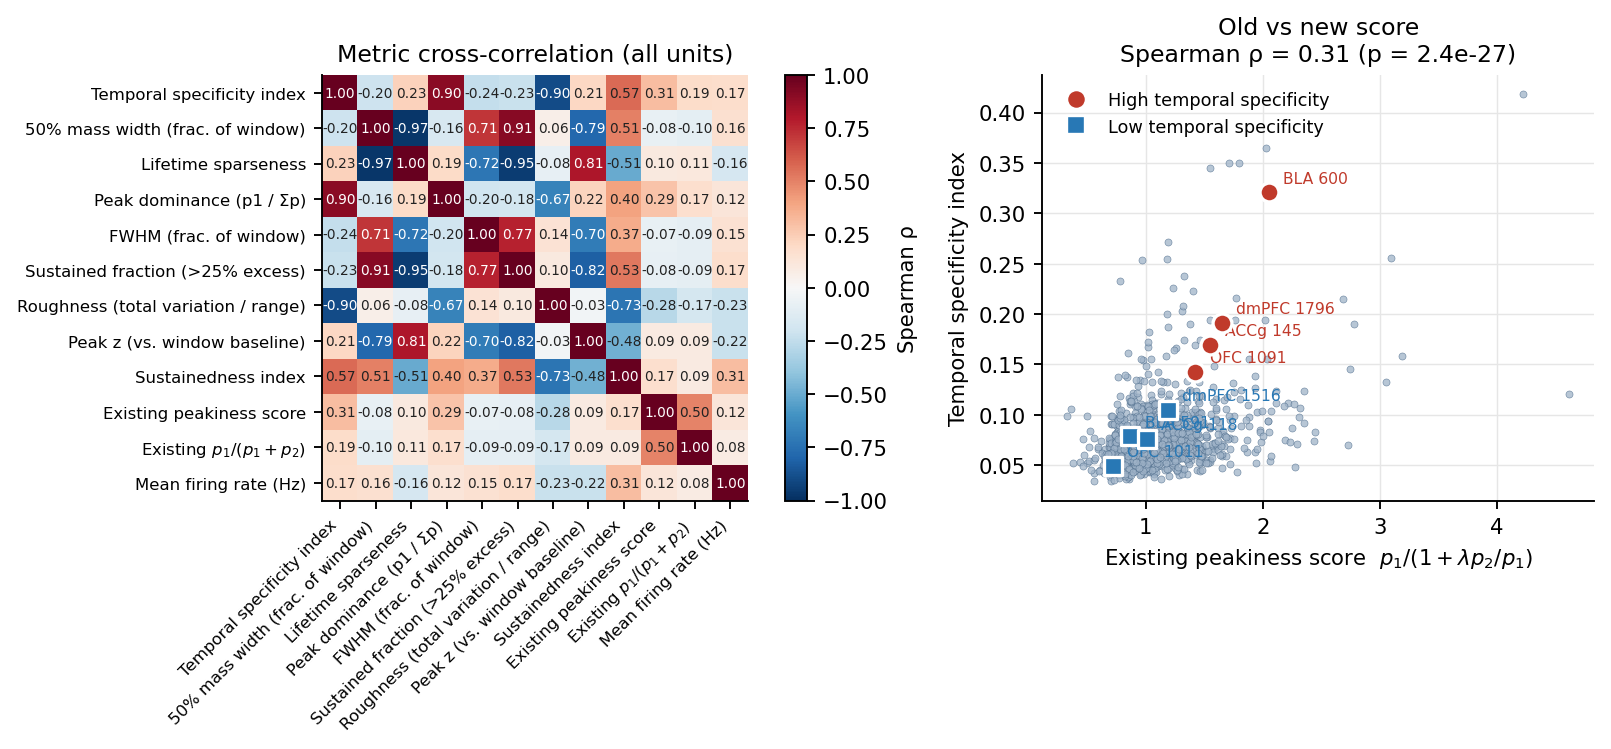

In [17]:
CORR_METRICS = RANK_METRICS + ["peakiness_score", "best_peak_dominance", "mean_fr_hz"]
CORR_LABELS = dict(METRIC_LABELS)
CORR_LABELS.update(
    {
        "peakiness_score": "Existing peakiness score",
        "best_peak_dominance": "Existing $p_1/(p_1+p_2)$",
        "mean_fr_hz": "Mean firing rate (Hz)",
    }
)
corr = units.loc[:, CORR_METRICS].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(10.6, 4.5), gridspec_kw={"width_ratios": [1.35, 1]})

ax = axes[0]
# Diverging scale with a neutral midpoint: correlation is a polarity measure.
image = ax.imshow(corr.to_numpy(), cmap="RdBu_r", vmin=-1, vmax=1)
labels = [CORR_LABELS.get(m, m.replace("_", " ")) for m in CORR_METRICS]
ax.set_xticks(range(len(CORR_METRICS)))
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
ax.set_yticks(range(len(CORR_METRICS)))
ax.set_yticklabels(labels, fontsize=7)
ax.grid(False)
for i in range(len(CORR_METRICS)):
    for j in range(len(CORR_METRICS)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=5.8,
                color="white" if abs(value) > 0.6 else "#222222")
fig.colorbar(image, ax=ax, fraction=0.045, label="Spearman ρ")
ax.set_title("Metric cross-correlation (all units)")

ax = axes[1]
ax.scatter(
    units["peakiness_score"],
    units["temporal_specificity_index"],
    s=9,
    c="#9fb3c8",
    edgecolor="#4c6b8a",
    linewidth=0.25,
    alpha=0.75,
)
for _, unit in EXEMPLARS.iterrows():
    ax.scatter(
        unit["peakiness_score"],
        unit["temporal_specificity_index"],
        s=64,
        color=STYLE_COLORS.get(unit["style"], ACCENT),
        marker=STYLE_MARKERS.get(unit["style"], "o"),
        edgecolor="white",
        linewidth=1.4,           # 2px-equivalent surface ring on overlapping marks
        zorder=6,
    )
    ax.annotate(
        unit["label"],
        (unit["peakiness_score"], unit["temporal_specificity_index"]),
        textcoords="offset points",
        xytext=(6, 4),
        fontsize=6.6,
        color=STYLE_COLORS.get(unit["style"], ACCENT),
    )
rho, p_rho = stats.spearmanr(
    units["peakiness_score"], units["temporal_specificity_index"], nan_policy="omit"
)
ax.set_xlabel("Existing peakiness score  $p_1/(1+\\lambda p_2/p_1)$")
ax.set_ylabel("Temporal specificity index")
ax.set_title(f"Old vs new score\nSpearman ρ = {rho:.2f} (p = {p_rho:.1e})")
ax.legend(
    handles=[
        Line2D([0], [0], marker=STYLE_MARKERS.get(s, "o"), color="none",
               markerfacecolor=STYLE_COLORS.get(s, ACCENT), markeredgecolor="white",
               markersize=8, label=STYLE_LABELS[s])
        for s in ("phasic", "tonic")
    ],
    fontsize=7.5,
    loc="upper left",
)

fig.tight_layout()
show(fig)

### 4d · Where the population actually sits

Plotted against `sustained_frac` rather than `sustainedness_index`, because the two
composites share the smoothness factor and are therefore positively correlated
(ρ ≈ 0.57 in the matrix above) — that shared term makes them a poor pair of axes.
`sustained_frac` is the raw breadth measure and gives the honest trade-off.

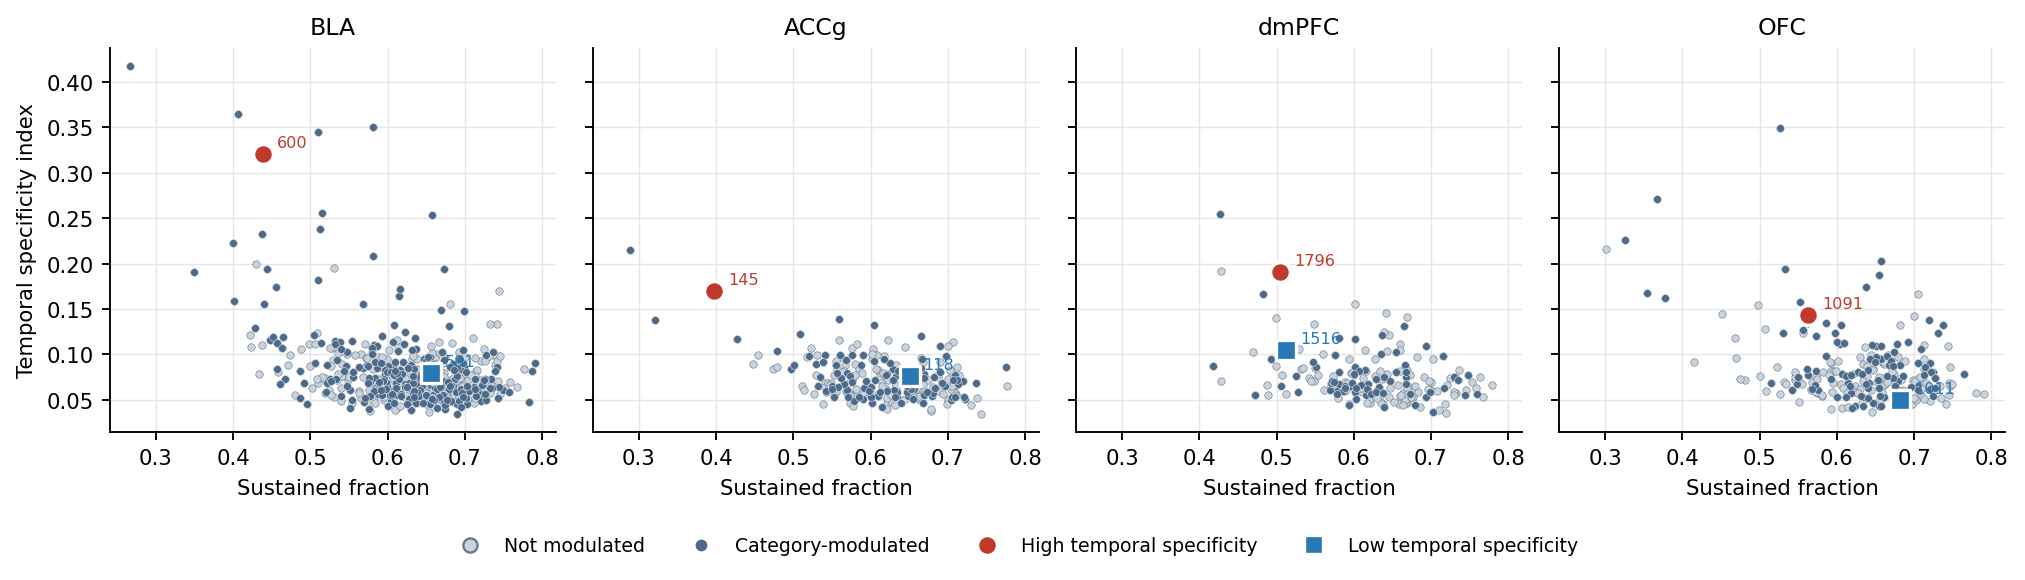

Most units sit in the lower-right lobe — **broadly elevated and ragged**, the modal profile. The narrow, single-peaked corner (upper left) is sparsely populated in every region, which is the quantitative form of the visual impression that few neurons show a sharp localized transient.

In [18]:
fig, axes = plt.subplots(1, len(REGIONS), figsize=(3.0 * len(REGIONS), 3.1), sharex=True, sharey=True)
for ax, region in zip(np.atleast_1d(axes), REGIONS):
    region_units = units.loc[units["region"] == region]
    ax.scatter(
        region_units["sustained_frac"],
        region_units["temporal_specificity_index"],
        s=10,
        c="#c9d3dd",
        edgecolor="#6b7a8a",
        linewidth=0.25,
    )
    selective_region = region_units.loc[region_units["is_selective"]]
    ax.scatter(
        selective_region["sustained_frac"],
        selective_region["temporal_specificity_index"],
        s=11,
        c="#4c6b8a",
        edgecolor="white",
        linewidth=0.2,
    )
    for _, unit in EXEMPLARS.loc[EXEMPLARS["region"] == region].iterrows():
        ax.scatter(
            unit["sustained_frac"],
            unit["temporal_specificity_index"],
            s=70,
            color=STYLE_COLORS.get(unit["style"], ACCENT),
            marker=STYLE_MARKERS.get(unit["style"], "o"),
            edgecolor="white",
            linewidth=1.4,
            zorder=6,
        )
        ax.annotate(
            unit["uuid"],
            (unit["sustained_frac"], unit["temporal_specificity_index"]),
            textcoords="offset points",
            xytext=(6, 3),
            fontsize=6.8,
            color=STYLE_COLORS.get(unit["style"], ACCENT),
        )
    ax.set_title(region_label(region))
    ax.set_xlabel("Sustained fraction")
np.atleast_1d(axes)[0].set_ylabel("Temporal specificity index")
handles = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#c9d3dd",
           markeredgecolor="#6b7a8a", markersize=6, label="Not modulated"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#4c6b8a",
           markeredgecolor="white", markersize=6, label="Category-modulated"),
] + [
    Line2D([0], [0], marker=STYLE_MARKERS.get(s, "o"), color="none",
           markerfacecolor=STYLE_COLORS.get(s, ACCENT), markeredgecolor="white",
           markersize=8, label=STYLE_LABELS[s])
    for s in ("phasic", "tonic")
]
fig.legend(handles=handles, ncol=4, loc="lower center", fontsize=8, bbox_to_anchor=(0.5, -0.10))
fig.tight_layout()
show(fig)

display(
    Markdown(
        "Most units sit in the lower-right lobe — **broadly elevated and ragged**, "
        "the modal profile. The narrow, single-peaked corner (upper left) is sparsely "
        "populated in every region, which is the quantitative form of the visual "
        "impression that few neurons show a sharp localized transient."
    )
)

## 5 · The responsive subpopulation, region by region

The hierarchy the rest of the notebook builds toward:

```
region
└── units that differentiate at least one fixation pair in at least one window (FDR corrected)
    ├── how many, and via which pair × window
    ├── exemplifying neurons, chosen on the metrics
    └── metric distributions vs. the non-modulated remainder
```

### 5a · The hierarchy as a table

In [19]:
hierarchy_rows = []
for region in REGIONS:
    region_units = units.loc[units["region"] == region]
    selective_region = region_units.loc[region_units["is_selective"]]
    region_pairs = pair_sel.loc[
        (pair_sel["region"] == region) & pair_sel["is_selective_pair_corrected"].astype(bool)
    ]
    entry = {
        "region": region_label(region),
        "units recorded": len(region_units),
        "category-modulated": len(selective_region),
        "fraction": len(selective_region) / len(region_units) if len(region_units) else np.nan,
        "1 pair": int((selective_region["n_selective_pairs"] == 1).sum()),
        "2 pairs": int((selective_region["n_selective_pairs"] == 2).sum()),
        "3 pairs": int((selective_region["n_selective_pairs"] == 3).sum()),
    }
    for pair in PAIRS:
        entry[PAIR_LABELS[pair]] = int((region_pairs["pair_label"] == pair).sum())
    for window in WINDOWS:
        entry[window] = int(window_counts.loc[region, window])
    hierarchy_rows.append(entry)

hierarchy = pd.DataFrame(hierarchy_rows).set_index("region")
display(hierarchy.style.format({"fraction": "{:.3f}"}).set_caption(
    "Counts are units; a unit may contribute to more than one pair or window column"
))

,units recorded,category-modulated,fraction,1 pair,2 pairs,3 pairs,Int face vs Non-int face,Int face vs Object,Non-int face vs Object,pre_fix,peri_fix,post_fix
region,,,,,,,,,,,,
BLA,537,287,0.534,87,159,41,162,221,145,220,230,245
ACCg,236,105,0.445,35,58,12,63,67,57,81,83,81
dmPFC,187,73,0.390,23,42,8,39,52,40,57,57,60
OFC,241,109,0.452,33,68,8,57,83,53,79,85,87


### 5b · Metric distributions within the responsive subpopulation

Does being fixation-category-modulated go with a particular temporal profile? Each
metric is compared between modulated and non-modulated units within region
(Mann–Whitney *U*, two-sided), FDR corrected across the region × metric family.

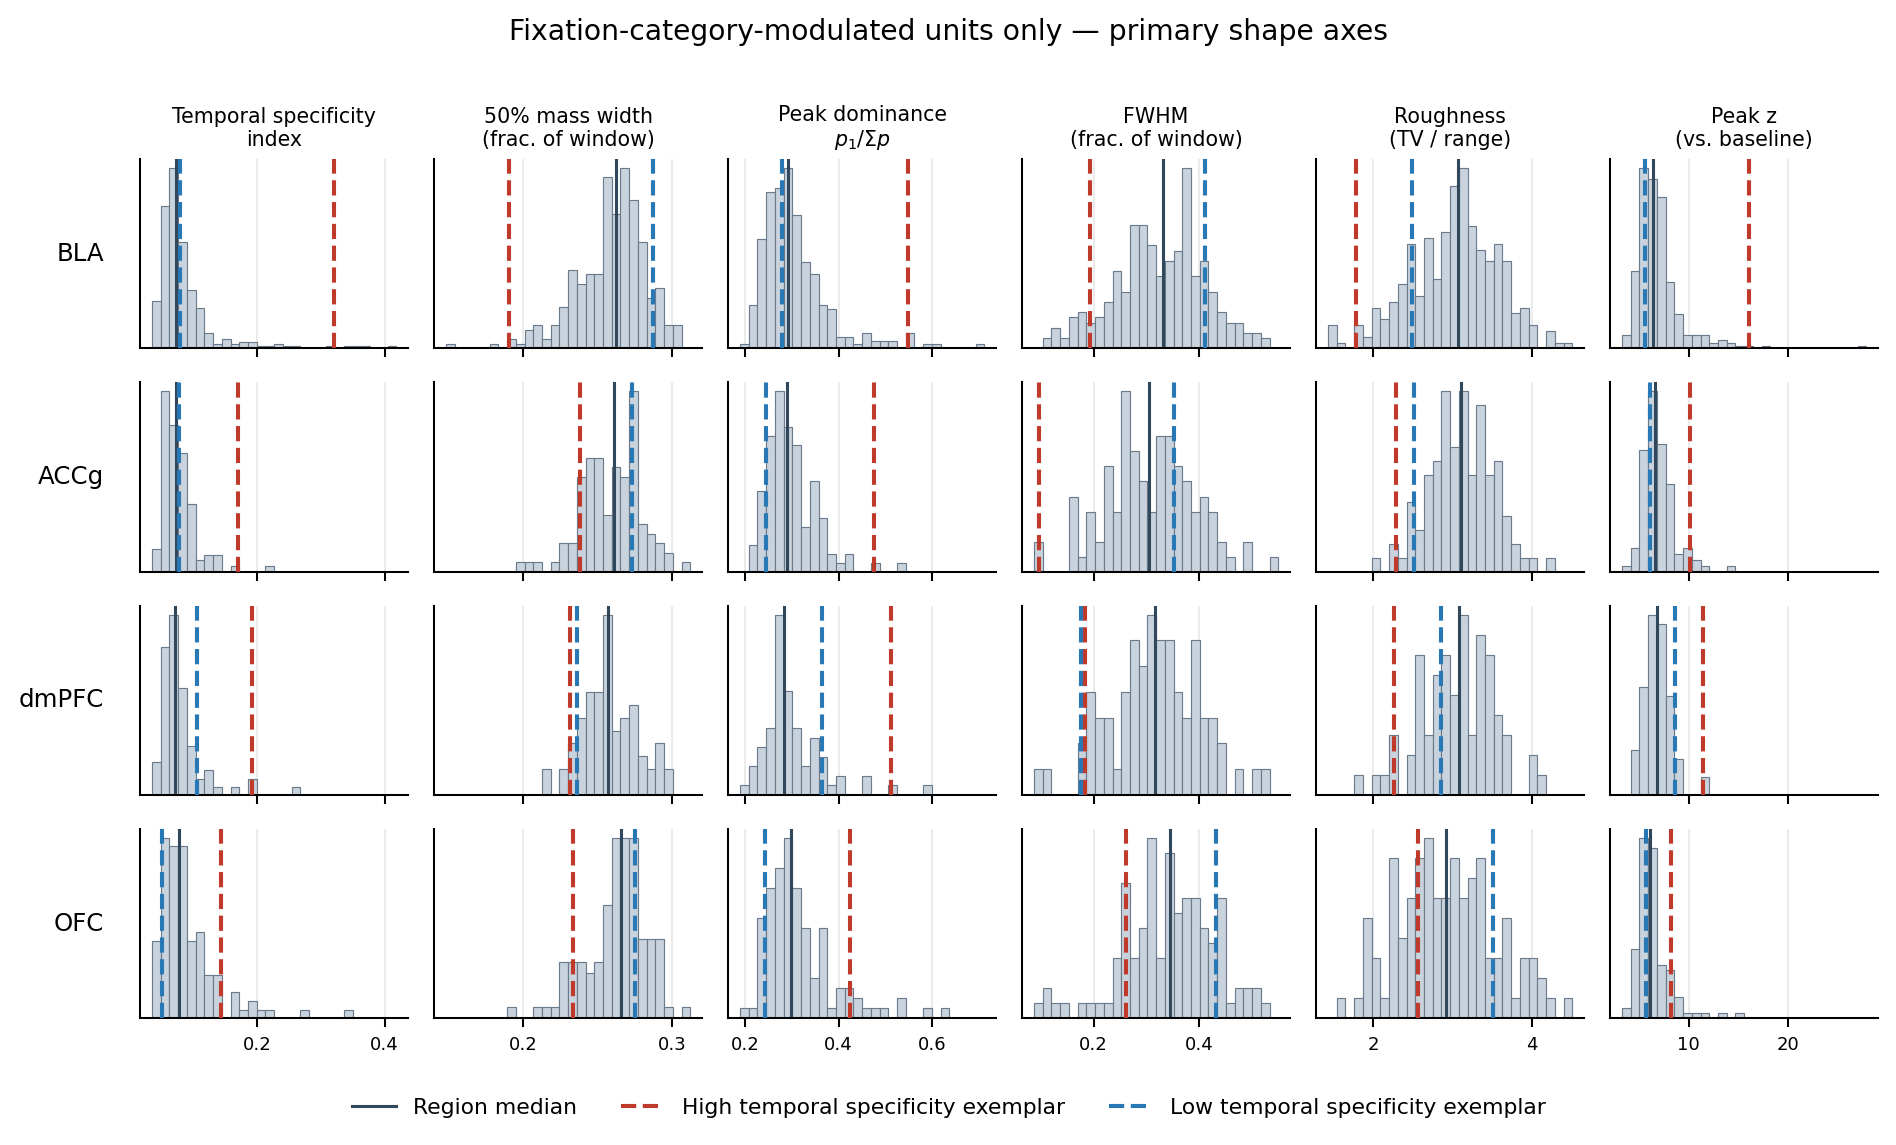

,region,metric,median_modulated,median_other,n_modulated,n_other,effect_r,p_value,p_adj,significant
35,OFC,Sustainedness index,0.220,0.201,109,132,0.200,0.008,0.137,False
33,OFC,Roughness (total variation / range),2.924,3.101,109,132,-0.207,0.006,0.137,False
27,OFC,Temporal specificity index,0.077,0.071,109,132,0.165,0.027,0.261,False
23,dmPFC,Sustained fraction (>25% excess),0.607,0.641,73,114,-0.190,0.029,0.261,False
20,dmPFC,Lifetime sparseness,0.353,0.337,73,114,0.176,0.042,0.298,False
25,dmPFC,Peak z (vs. window baseline),6.829,6.313,73,114,0.170,0.050,0.298,False
24,dmPFC,Roughness (total variation / range),3.089,3.206,73,114,-0.158,0.069,0.309,False
19,dmPFC,50% mass width (frac. of window),0.257,0.262,73,114,-0.162,0.062,0.309,False
18,dmPFC,Temporal specificity index,0.070,0.065,73,114,0.146,0.092,0.348,False
22,dmPFC,FWHM (frac. of window),0.316,0.339,73,114,-0.130,0.135,0.348,False


**0/36 region × metric comparisons survive FDR correction.** Being fixation-category-modulated carries **no** detectable temporal-profile signature: responsive and unresponsive units have the same distribution of widths, peak dominance and raggedness. Selectivity and temporal specificity are independent properties of a unit, so the §4 metrics add information rather than restating §3.

In [20]:
show(
    metric_histograms(
        units.loc[units["is_selective"]],
        PRIMARY_METRICS,
        title="Fixation-category-modulated units only — primary shape axes",
        exemplars=EXEMPLARS.loc[EXEMPLARS["is_selective"]],
    ),
    dpi=185,
)

comparison_rows = []
for region in REGIONS:
    region_units = units.loc[units["region"] == region]
    group_a = region_units.loc[region_units["is_selective"]]
    group_b = region_units.loc[~region_units["is_selective"]]
    for metric in RANK_METRICS:
        a = pd.to_numeric(group_a[metric], errors="coerce").dropna().to_numpy()
        b = pd.to_numeric(group_b[metric], errors="coerce").dropna().to_numpy()
        if a.size < 3 or b.size < 3:
            continue
        statistic, p_value = stats.mannwhitneyu(a, b, alternative="two-sided")
        comparison_rows.append(
            {
                "region": region_label(region),
                "metric": METRIC_LABELS[metric],
                "median_modulated": float(np.median(a)),
                "median_other": float(np.median(b)),
                "n_modulated": int(a.size),
                "n_other": int(b.size),
                # Rank-biserial correlation: effect size on [-1, 1], the natural
                # companion to Mann-Whitney and unaffected by the very unequal ns.
                "effect_r": float(2.0 * statistic / (a.size * b.size) - 1.0),
                "p_value": float(p_value),
            }
        )

comparison = pd.DataFrame(comparison_rows)
comparison["p_adj"] = adjust_pvalues(comparison["p_value"].to_numpy(), CORRECTION)
comparison["significant"] = comparison["p_adj"] < ALPHA
display(
    comparison.sort_values("p_adj")
    .head(20)
    .style.format(precision=3)
    .set_caption("Modulated vs non-modulated units, top 20 by FDR-adjusted p")
)
n_significant = int(comparison["significant"].sum())
display(
    Markdown(
        f"**{n_significant}/{len(comparison)} region × metric comparisons survive FDR correction.** "
        + (
            "Being fixation-category-modulated carries **no** detectable temporal-profile "
            "signature: responsive and unresponsive units have the same distribution of "
            "widths, peak dominance and raggedness. Selectivity and temporal specificity are "
            "independent properties of a unit, so the §4 metrics add information rather than "
            "restating §3."
            if n_significant == 0
            else "See the table above for which axes differ."
        )
    )
)

### 5c · Exemplifying neurons, selected on the metrics

For each region, the most extreme **category-modulated** unit on each shape axis:
the narrowest single-peaked response, and the broadest response among units that are
not narrow. These are the data-driven counterparts to the hand-picked exemplars in
§2b, and the candidates for replacing dmPFC 1516.

In [21]:
def top_units(frame: pd.DataFrame, metric: str, *, ascending: bool, n: int = 3) -> pd.DataFrame:
    picked = frame.sort_values(metric, ascending=ascending).head(n)
    return picked.loc[
        :,
        ["region_label", "date", "uuid", "mean_fr_hz", "peak_fr_hz", "dominant_condition",
         "temporal_specificity_index", "sustainedness_index", "fwhm_frac", "roughness",
         "peak_dominance", "peak_z"],
    ]


candidate_frames = []
for region in REGIONS:
    pool = units.loc[
        (units["region"] == region)
        & units["is_selective"]
        & units["any_condition_modulated"].astype(bool)
    ]
    high = top_units(pool, "temporal_specificity_index", ascending=False)
    high.insert(0, "role", "high temporal specificity")
    # The "broad" exemplar is the widest response among units that are *not*
    # narrow. A roughness gate is deliberately NOT applied here -- see the count
    # below: smooth broad plateaus essentially do not occur in this dataset, so
    # gating on smoothness empties the pool rather than improving the pick.
    broad_pool = pool.loc[
        pool["temporal_specificity_index"] <= pool["temporal_specificity_index"].median()
    ]
    low = top_units(broad_pool, "sustained_frac", ascending=False)
    low.insert(0, "role", "broad / low specificity")
    candidate_frames.extend([high, low])

candidates = pd.concat(candidate_frames, ignore_index=True)
candidates["currently_configured"] = candidates["uuid"].isin(EXEMPLARS["uuid"])
display(
    candidates.style.format(precision=2).set_caption(
        "Top 3 candidate exemplars per region per role; "
        "`currently_configured` flags units already in ephys_fixation_psth.yaml"
    )
)

# How rare is a smooth, broadly elevated unit? Roughness ~1 means a single
# monotone excursion; ~3 (the population median) means about three reversals.
smooth_broad = units.loc[
    units["is_selective"] & (units["roughness"] < 2.0) & (units["sustained_frac"] > 0.60)
]
narrow_smooth = units.loc[units["is_selective"] & (units["roughness"] < 2.0)]
display(
    Markdown(
        f"""
**There is no smooth-plateau cell type here.** Among the {int(units['is_selective'].sum())}
fixation-category-modulated units, only **{len(narrow_smooth)}** have `roughness` < 2
(i.e. essentially one excursion), and of those only **{len(smooth_broad)}** are also
broadly elevated (`sustained_frac` > 0.60). Roughness and the specificity index are
strongly anti-correlated (ρ ≈ −0.90), so *the smooth units are precisely the narrow
ones*. Breadth in this population comes from **many comparable peaks**, not from a
sustained plateau — which is why the broad exemplars below still look jittery, and
why `roughness` has to be reported alongside any width measure rather than folded
into it.
"""
    )
)

,role,region_label,date,uuid,mean_fr_hz,peak_fr_hz,dominant_condition,temporal_specificity_index,sustainedness_index,fwhm_frac,roughness,peak_dominance,peak_z,currently_configured
0,high temporal specificity,BLA,1092019,2590,4.27,9.88,face_interactive,0.42,0.17,0.11,1.51,0.71,27.81,False
1,high temporal specificity,BLA,1052019,2518,21.57,28.17,face_interactive,0.36,0.28,0.13,1.48,0.61,13.98,False
2,high temporal specificity,BLA,9292018,789,18.01,25.79,face_interactive,0.35,0.48,0.37,1.43,0.51,8.31,False
3,broad / low specificity,BLA,1092019,2619,11.49,12.43,face_interactive,0.05,0.21,0.50,3.70,0.25,4.53,False
4,broad / low specificity,BLA,2022018,570,11.58,13.97,object,0.06,0.22,0.45,3.42,0.27,4.73,False
5,broad / low specificity,BLA,1052019,2526,27.94,29.37,face_interactive,0.06,0.23,0.41,3.32,0.28,5.03,False
6,high temporal specificity,ACCg,1172019,380,2.96,7.90,object,0.22,0.14,0.10,2.02,0.54,10.90,False
7,high temporal specificity,ACCg,1302018,145,2.47,4.94,face_non_interactive,0.17,0.17,0.10,2.28,0.48,10.12,True
8,high temporal specificity,ACCg,1162018,113,8.31,12.68,face_non_interactive,0.14,0.25,0.30,2.29,0.39,6.84,False
9,broad / low specificity,ACCg,10032018,249,3.65,5.88,object,0.07,0.24,0.43,3.10,0.30,4.92,False



**There is no smooth-plateau cell type here.** Among the 574
fixation-category-modulated units, only **23** have `roughness` < 2
(i.e. essentially one excursion), and of those only **6** are also
broadly elevated (`sustained_frac` > 0.60). Roughness and the specificity index are
strongly anti-correlated (ρ ≈ −0.90), so *the smooth units are precisely the narrow
ones*. Breadth in this population comes from **many comparable peaks**, not from a
sustained plateau — which is why the broad exemplars below still look jittery, and
why `roughness` has to be reported alongside any width measure rather than folded
into it.


### 5d · Candidate exemplar traces

The condition-average traces of the top candidate in each role, drawn straight from
the scored trace store — a fast visual check before promoting any of them into the
config. (Full raster panels for a chosen set are produced by re-running §2 with the
config updated.)

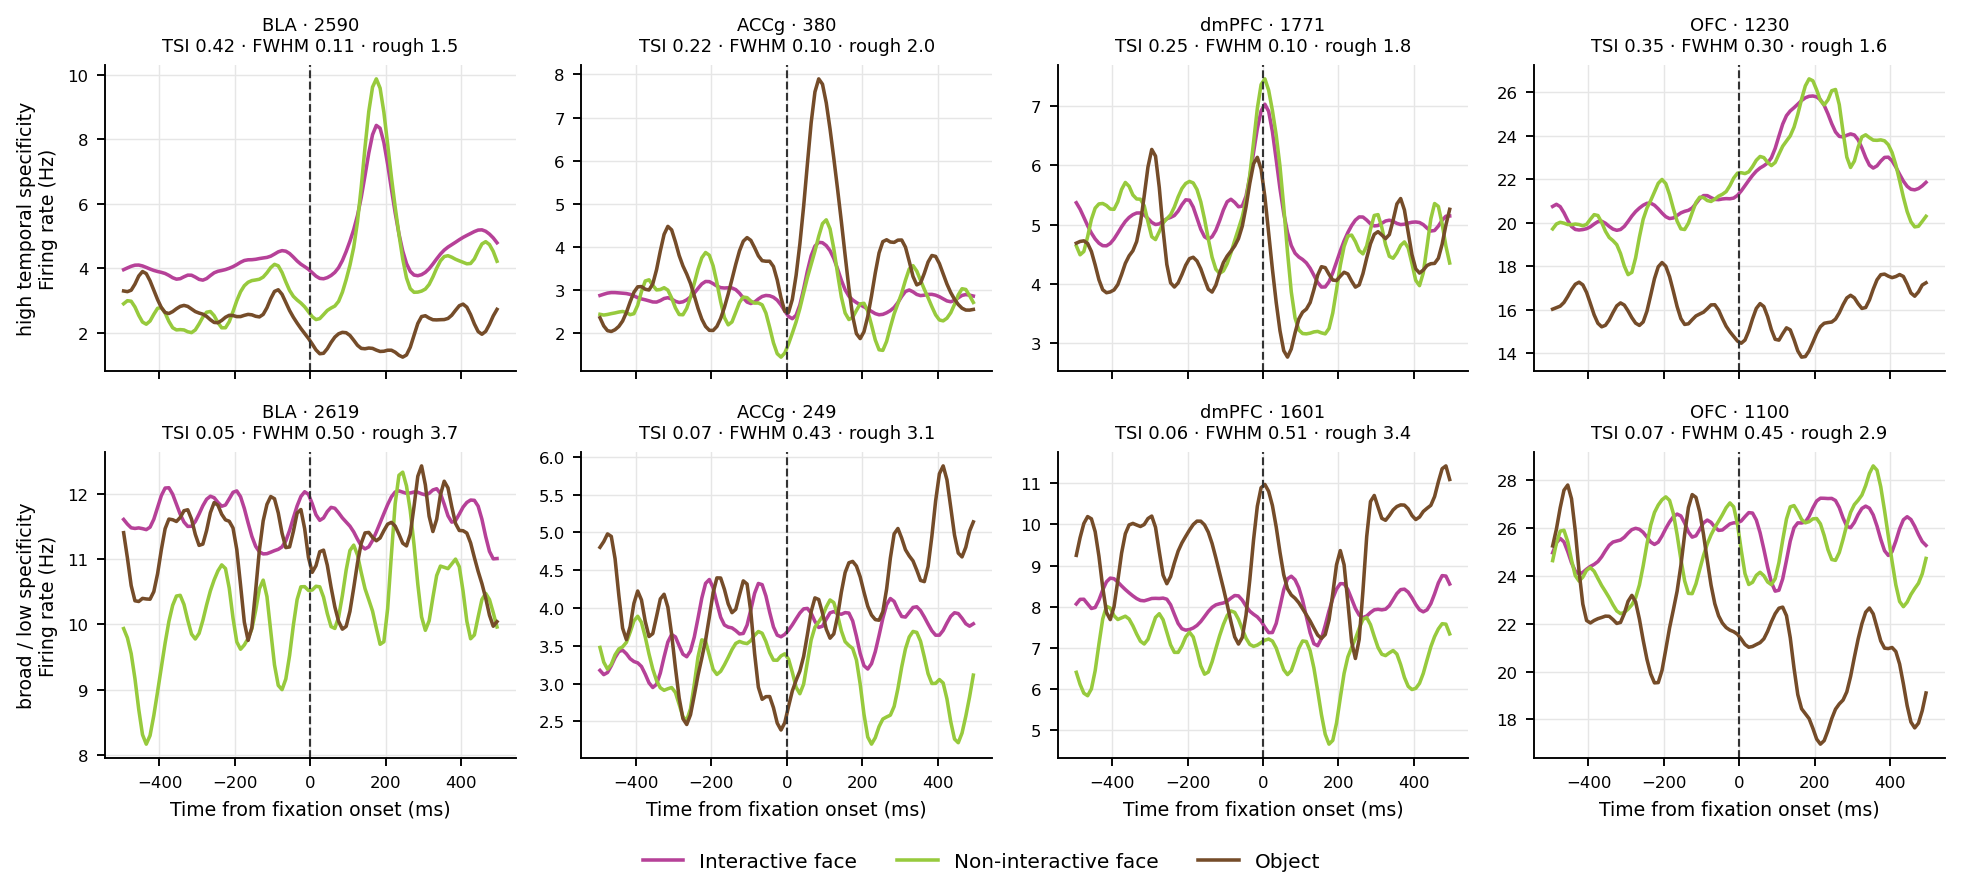

In [22]:
trace_lookup = {
    (row.unit_key, row.condition): (row.bin_centers_s_rel, row.trace_hz)
    for row in condition_traces.itertuples()
}

top_choice = (
    candidates.merge(units.loc[:, ["uuid", "region", "unit_key"]], on="uuid", how="left")
    .groupby(["region_label", "role"], sort=False)
    .head(1)
)

fig, axes = plt.subplots(2, len(REGIONS), figsize=(2.9 * len(REGIONS), 5.0), sharex=True)
roles = ["high temporal specificity", "broad / low specificity"]
for row_idx, role in enumerate(roles):
    for col_idx, region in enumerate(REGIONS):
        ax = axes[row_idx][col_idx]
        picked = top_choice.loc[
            (top_choice["role"] == role) & (top_choice["region_label"] == region_label(region))
        ]
        if picked.empty:
            ax.set_axis_off()
            continue
        unit = picked.iloc[0]
        for condition in CONDITIONS:
            entry = trace_lookup.get((unit["unit_key"], condition))
            if entry is None:
                continue
            centers_ms, trace = np.asarray(entry[0]) * 1000.0, np.asarray(entry[1])
            mask = (centers_ms >= -500.0) & (centers_ms <= 500.0)
            ax.plot(
                centers_ms[mask],
                trace[mask],
                color=CONDITION_COLORS[condition],
                linewidth=1.5,
                label=CONDITION_LABELS[condition] if (row_idx == 0 and col_idx == 0) else None,
            )
        ax.axvline(0.0, color="#333333", linestyle="--", linewidth=0.9)
        ax.set_title(
            f"{region_label(region)} · {unit['uuid']}\n"
            f"TSI {unit['temporal_specificity_index']:.2f} · "
            f"FWHM {unit['fwhm_frac']:.2f} · rough {unit['roughness']:.1f}",
            fontsize=7.6,
        )
        if col_idx == 0:
            ax.set_ylabel(f"{role}\nFiring rate (Hz)", fontsize=8)
        if row_idx == 1:
            ax.set_xlabel("Time from fixation onset (ms)", fontsize=8)
        ax.tick_params(labelsize=7)

fig.legend(ncol=3, loc="lower center", fontsize=8.5, bbox_to_anchor=(0.5, -0.055))
fig.tight_layout()
show(fig)

## 6 · Persist the summary tables

In [23]:
exports = {
    "recording_inventory.csv": inventory,
    "modulated_fraction_by_region.csv": modulated,
    "modulated_fraction_pairwise_tests.csv": pairwise_region_tests(modulated, label="modulated_fraction"),
    "preference_counts_by_region.csv": pref_counts,
    "preference_goodness_of_fit.csv": gof,
    "selectivity_hierarchy.csv": hierarchy,
    "temporal_specificity_exemplar_ranks.csv": exemplar_ranks,
    "temporal_specificity_modulated_vs_other.csv": comparison,
    "temporal_specificity_exemplar_candidates.csv": candidates,
}
for filename, frame in exports.items():
    path = OUT_DIR / filename
    frame.to_csv(path, index=not isinstance(frame.index, pd.RangeIndex))
    print(f"wrote {path.relative_to(ANALYSIS_ROOT.parent.parent)}  ({len(frame)} rows)")

wrote ephys/psth/single_unit_notebook/recording_inventory.csv  (5 rows)
wrote ephys/psth/single_unit_notebook/modulated_fraction_by_region.csv  (4 rows)
wrote ephys/psth/single_unit_notebook/modulated_fraction_pairwise_tests.csv  (6 rows)
wrote ephys/psth/single_unit_notebook/preference_counts_by_region.csv  (4 rows)
wrote ephys/psth/single_unit_notebook/preference_goodness_of_fit.csv  (4 rows)
wrote ephys/psth/single_unit_notebook/selectivity_hierarchy.csv  (4 rows)
wrote ephys/psth/single_unit_notebook/temporal_specificity_exemplar_ranks.csv  (8 rows)
wrote ephys/psth/single_unit_notebook/temporal_specificity_modulated_vs_other.csv  (36 rows)
wrote ephys/psth/single_unit_notebook/temporal_specificity_exemplar_candidates.csv  (24 rows)


## Summary

1. **Yield and modulation.** Of 1201 isolated units, the fraction differentiating at
   least one fixation-category pair in at least one window (FDR corrected) is far
   from uniform across regions — §3a. BLA is the most responsive; ACCg the least.
2. **Preference.** Among modulated units, interactive-face preference is the modal
   outcome in BLA, dmPFC and OFC but not in ACCg, where the three categories are
   near-evenly preferred — §3c. The pipeline's current counts are lower than those
   quoted in the manuscript paragraph; the definition needs to be pinned down.
3. **Temporal specificity.** The prominence-ratio score conflates amplitude, width
   and raggedness. Separating them shows the population is dominated by **broad,
   ragged elevation**, with a thin tail of genuinely narrow single-peak responses —
   §4a, §4d. That matches the visual impression and is not visible in the old score.
4. **There is no smooth-plateau cell type.** Roughness and the specificity index are
   anti-correlated at ρ ≈ −0.90: the smooth units *are* the narrow ones. Broad
   responses in this dataset are built from many comparable peaks, so "phasic vs
   tonic" is the wrong dichotomy — the real contrast is **narrow-and-clean vs
   broad-and-ragged**, and `roughness` must be reported next to any width measure
   rather than folded into a single score — §5c.
5. **Exemplars.** Three of the four configured *tonic* exemplars are consistent with
   the metrics; **dmPFC 1516 is not** — it is narrow and multi-peaked, not sustained.
   §5c lists metric-selected replacements for each region, and the traces in §5d show
   the metric-selected narrow exemplars are considerably cleaner than the hand-picked
   ones.

**Next steps worth taking:** reconcile the preference-count definition against the
manuscript; decide whether `temporal_specificity_index` or the individual axes go into
the figure; and if the exemplar set is revised, update
`phasic_tonic_example_grid_units` in `configs/ephys_fixation_psth.yaml` and re-run §2
with `FORCE_RERENDER = True`.